# Week 6 · Mini Project 3: Multimodal Participation

### Two records of the same session, for 39 pairs of children solving a problem with a robot

**EDIS 8100: Teaching and Learning Analytics**

Session: Wednesday, September 30, 2026. The notebook portion runs from 4:50 to 5:50 PM, after the student-led discussion hour and the break.

Fall 2026 · Dr. Hakeoung Hannah Lee · University of Virginia

---

Thirty-nine pairs of children, aged nine to twelve, worked at two screens with a robot on connecting a map of Switzerland with the cheapest possible set of edges. A logger recorded every edge each child added and removed. For ten of those pairs, the release also carries a dialogue transcript, from which speech seconds, speaking turns, and word counts per child were derived.

So for twenty children there are two independent records of the same session: **what the transcript recorded** and **what the event log recorded**.

The question is: **who participated?** The two records do not agree everywhere, and that disagreement is what this notebook examines.

The same release carries two further channels, recorded at the level of the **pair** rather than the child: where the children looked, at their partner, at each screen, or at the robot, and affect estimates, including valence, arousal, and a smile count. Setting those beside the per-child channels raises a further question: what can a team-level measure say about an individual?

We work through the first sections together in class, and no cell asks you to write code from a blank page.

### What I hope you leave with

1. Being able to read a real multimodal corpus at its true grain, including the part most published analyses pass over: which children have which channels, and what changes when only the children with both are kept.
2. Being able to compare two channels of participation on the same children, and to state with an interval, rather than a point estimate, how much one tells you about the other.
3. Recognizing non-independence when rows nest inside pairs, including the case where two rows are mathematically forced to mirror each other.
4. Separating a between-team association from a within-team one, and being able to say why an individual participation grade needs the second and why this corpus supplies only the first.
5. Auditing a dataset for what it does not record, and, in the memo, discussing what that absence does to an equity question.

## How to work through this notebook

- Run cells **top to bottom**. Click a cell, then press **Shift + Enter**, or use the play button at the left of the cell.
- This runs on a temporary machine in the cloud, working on a copy of four published files. The notebook only reads them, and it writes nothing to your computer or to the course repository. If something goes wrong, `Runtime > Restart session and run all` resolves almost everything.
- In Colab, **File > Save a copy in Drive** keeps a personal version. For a graded project that matters more than usual, since the copy in Drive is what you will download and submit.
- Cells marked **Your turn** already hold a working value. You can run the whole notebook without editing anything and nothing will be missing.
- The section marked **Going further** near the end is optional.
- The numbers in the prose were produced by the cells you are about to run. If one of them does not match what you see, it may be worth telling me.

### The route for today

| | Sections |
|---|---|
| **CORE, about 55 to 60 minutes** | Setup; 1 and 1.1; 2 and 2.1; 3; 4; 5, 5.1 and 5.2 |
| **IF TIME** | The Your turn 1, 2 and 3 edits; 6 |
| **EXPLORE LATER** | 7.1's verification task; Your turn 4; Going further; the appendix |

This is a mini project, so sections 6 through 11 are completed outside class before the due date, and the memo requires 6 and 7: memo items 1 and 5 use the fragility checks and the missing column. The class hour covers objectives 1 to 4; the memo covers objective 5.


**What is assessed.** This notebook is submitted as Mini Project 3 and goes to Canvas. Coding skill is not what is assessed. The **interpretation memo in Section 10 is the primary component used for grading**, and the interpretation cells throughout are the notes you will draw on to write it. Editing a **Your turn** value is a way of seeing what a choice was doing to a result rather than a task you are scored on.

**If you work in R, SPSS, or Stata, or have not written code before,** you might find it useful to read the code the way you read a methods section: you are checking what was done to the data, not memorizing syntax. Two patterns cover most of what we use. Square brackets after a table, as in `df[df.score > 50]`, select a subset, like `subset()` or a filter. A line ending in `.mean()`, `.sum()`, or `.value_counts()` summarizes, like `aggregate()` or a frequency table. When a line does not make sense, please ask.

---

## Setup: where this data comes from



### The dataset

Two companion corpora come from the same study, both released by the **CHILI lab at EPFL** in Switzerland.

**1. The JUSThink Dialogue and Actions Corpus.** Anonymized dialogue transcripts, interface event logs, and pre-test and post-test responses from **39 teams of two children, aged 9 to 12**. All 39 teams have event logs and test scores. **10 of the 39 have full dialogue transcripts**, which is why the speech columns are mostly empty, and Section 1.1 is about what to do with that.

**2. PE-HRI and PE-HRI-temporal.** The same activity, described at the level of the **team** rather than the child: interface behavior, speech activity, gaze, affect, and learning outcomes for **34 teams**, plus a temporal file that re-describes **32 of those teams in 10-second windows**.

### The activity

Two children, each at their own screen, share one map of Switzerland whose nodes carry Swiss city names (Nasir et al., 2021). Their job is to connect every node using the cheapest possible set of edges: the **minimum spanning tree** problem. A humanoid robot, a QTrobot, acts as guide and mediator (Nasir et al., 2021). Before and after, each child takes a **10-item test** of the underlying idea. `gain` is post minus pre, so it runs from -10 to +10 and in practice runs from -3 to +3.

### What we are using

We use four files, packaged for this course at `github.com/HakeoungLee/edis8100-datasets`. Nothing was altered except the joining, the packaging, and seven share-of-pair columns added to the joined file.

| File | Rows | One row is |
|---|---|---|
| `per_participant.csv` | 78 | one child |
| `participant_with_team_channels.csv` | 68 | one child, joined to that team's channel summary |
| `pehri_team_outcomes.csv` | 34 | one team's error and learning-gain measures |
| `pehri_temporal.csv.gz` | 4,676 | one team in one 10-second window |

### License

**CC BY 4.0** for both corpora. You may use, adapt, and redistribute them, including commercially, as long as you give credit. That is a permissive license.

### How to cite them

> Norman, U., Dinkar, T., Nasir, J., Bruno, B., Clavel, C., & Dillenbourg, P. (2021). *JUSThink Dialogue and Actions Corpus* [Data set]. Zenodo. https://doi.org/10.5281/zenodo.4627104

> Nasir, J., Norman, U., Bruno, B., Chetouani, M., & Dillenbourg, P. (2021). *PE-HRI: A multimodal dataset for the study of productive engagement in a robot-mediated collaborative educational setting* [Data set]. Zenodo. https://doi.org/10.5281/zenodo.4633092
>
> Nasir, J., Bruno, B., & Dillenbourg, P. (2024). *PE-HRI-temporal: A multimodal temporal dataset in a robot mediated collaborative educational setting* [Data set]. Zenodo. https://doi.org/10.5281/zenodo.13834073

### The one-line story

Seventy-eight children aged nine to twelve, in teams of two, worked with a robot on a problem about connecting nodes on a map of Switzerland; the sessions in the temporal file run from 11 to 36 minutes. The research team ran the sessions, transcribed ten of the pairs, derived gaze and affect features from the recordings, wrote the pre and post tests, removed identifiers, and released the result on Zenodo under a license that permits this reuse.

**Run the cell below.** It fetches four files over the internet.

In [1]:
%matplotlib inline

# =============================================================================
# Imports, then the four data files, then a confirmation that they arrived.
# No downloads to your computer, no logins, no API keys. Takes a second or two.
# =============================================================================
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BASE = "https://raw.githubusercontent.com/HakeoungLee/edis8100-datasets/main/justhink"

try:
    children  = pd.read_csv(f"{BASE}/per_participant.csv")
    joined    = pd.read_csv(f"{BASE}/participant_with_team_channels.csv")
    team_out  = pd.read_csv(f"{BASE}/pehri_team_outcomes.csv")
    temporal  = pd.read_csv(f"{BASE}/pehri_temporal.csv.gz")
    DATA_OK = True
except Exception:
    DATA_OK = False
    print("=" * 78)
    print("The data did not download.")
    print("Here is what to check, in order:")
    print()
    print("  1. Are you online? Reload any web page to be sure.")
    print("  2. Run this cell again. Transient failures are common.")
    print("  3. Open this in a browser tab and confirm it loads:")
    print("     https://github.com/HakeoungLee/edis8100-datasets")
    print("  4. If you are on a locked-down campus, school, or hospital network,")
    print("     it may be blocking raw.githubusercontent.com. Try another network,")
    print("     or run this notebook in Google Colab instead.")
    print()
    print("Still failing after all four? Please post on Canvas with a screenshot.")
    print("=" * 78)

if DATA_OK:
    pd.set_option('display.width', 170)
    pd.set_option('display.max_columns', 60)
    plt.rcParams.update({
        'figure.dpi': 110,
        'figure.autolayout': True,
        'axes.titlesize': 12,
        'axes.labelsize': 11,
        'axes.grid': True,
        'grid.alpha': 0.30,
    })

    SEED = 8100          # the course seed, so your numbers match your classmates'

    # Okabe-Ito, a colorblind-safe palette. Nothing in this notebook asks you to
    # tell red from green, and every distinction also has a shape or a line style.
    BLUE, ORANGE, GREEN, PURPLE, SKY, GOLD, GREY = (
        '#0072B2', '#D55E00', '#009E73', '#CC79A7', '#56B4E9', '#E69F00', '#8a8a8a')

    print("Data arrived. Here is what you have.\n")
    print(f"  per_participant.csv                {children.shape[0]:>5,} rows x {children.shape[1]:>2} cols"
          f"   (one child)")
    print(f"  participant_with_team_channels.csv {joined.shape[0]:>5,} rows x {joined.shape[1]:>2} cols"
          f"   (one child + team channels)")
    print(f"  pehri_team_outcomes.csv            {team_out.shape[0]:>5,} rows x {team_out.shape[1]:>2} cols"
          f"   (one team)")
    print(f"  pehri_temporal.csv.gz              {temporal.shape[0]:>5,} rows x {temporal.shape[1]:>2} cols"
          f"   (one team, one 10-second window)")
    print()
    print(f"  {children.shape[0]} children in {children['team_no'].nunique()} teams of two, aged 9 to 12.")
    print(f"  {int(children['speech_secs'].notna().sum())} of them also have a transcribed speech record.")
    print()
    print("JUSThink and PE-HRI, CHILI lab, EPFL. CC BY 4.0.")
    print("Norman et al. (2021), Zenodo 4627104. Nasir et al. (2021), Zenodo 4633092.")

Data arrived. Here is what you have.

  per_participant.csv                   78 rows x 12 cols   (one child)
  participant_with_team_channels.csv    68 rows x 48 cols   (one child + team channels)
  pehri_team_outcomes.csv               34 rows x  6 cols   (one team)
  pehri_temporal.csv.gz              4,676 rows x 59 cols   (one team, one 10-second window)

  78 children in 39 teams of two, aged 9 to 12.
  20 of them also have a transcribed speech record.

JUSThink and PE-HRI, CHILI lab, EPFL. CC BY 4.0.
Norman et al. (2021), Zenodo 4627104. Nasir et al. (2021), Zenodo 4633092.


---

## 1. The grain of each file

Before any analysis, it helps to know what one row of each file means. Getting the **grain** wrong leads to averaging an average.

- `children`: **one row per child.** 78 rows, two per team.
- `joined`: **one row per child**, with that team's channel summary repeated on both of the team's rows. Two children in the same team therefore carry identical gaze, affect, and overlap values. Those columns are not about either of them individually.
- `team_out`: **one row per team.**
- `temporal`: **one row per team per 10-second window.** No child appears in it at all.

**Run the cell below.** It prints the shape and the column names of three of the four files. 

In [2]:
print('CHILDREN, one row per child')
print('  shape:', children.shape)
print('  columns:', list(children.columns))
print()
print(children.head(6).to_string(index=False))
print()
print(f"  {children['team_no'].nunique()} teams, "
      f"{children.groupby('team_no').size().min()} to {children.groupby('team_no').size().max()} children each.")
print(f"  Every team has exactly two children: "
      f"{(children.groupby('team_no').size() == 2).all()}")
print()
print('TEAM OUTCOMES, one row per team')
print('  shape:', team_out.shape, ' columns:', [c for c in team_out.columns if c != 'Unnamed: 0'])
print()
print('TEMPORAL, one row per team per 10-second window')
print('  shape:', temporal.shape)
step = temporal.sort_values(['team', 'window']).groupby('team')['time_in_secs'].diff().dropna().unique()
print(f"  Time between consecutive rows of the same team: {sorted(step)} seconds. Only one value, so the grid is even.")
mins = temporal.groupby('team')['time_in_secs'].max() / 60
print(f"  {temporal['team'].nunique()} teams, sessions running {mins.min():.1f} to {mins.max():.1f} minutes "
      f"(median {mins.median():.1f}).")
print(f"  {mins.sum() / 60:.1f} hours of recorded interaction in total.")
print(f"  Is there a column identifying which child? {'who' in temporal.columns}")
print()
parts = children[['adds', 'removes', 'presses']].sum(axis=1)
over = children['actions'] - parts
print(f"  actions equals adds + removes + presses in {int((over == 0).sum())} of {len(children)} rows and exceeds it")
print(f"  by {int(over[over > 0].min())} to {int(over.max())} in the other {int((over > 0).sum())}. actions is used as packaged.")
print(f"  Teams absent from the PE-HRI file: {sorted(set(children['team_no']) - set(joined['team_no']))}")
print(f"  Teams absent from the temporal file: {sorted(set(children['team_no']) - set(temporal['team'].astype(int)))}")


CHILDREN, one row per child
  shape: (78, 12)
  columns: ['team_no', 'who', 'actions', 'adds', 'removes', 'presses', 'speech_secs', 'turns', 'words', 'score_pre', 'score_post', 'gain']

 team_no who  actions  adds  removes  presses  speech_secs  turns  words  score_pre  score_post  gain
       6   A       41    23      6.0       12          NaN    NaN    NaN          5           4    -1
       6   B       37    14     13.0       10          NaN    NaN    NaN          6           6     0
       7   A      136    96      4.0       35      450.274  306.0 1468.0          7           7     0
       7   B      190    94     12.0       83      419.698  302.0 1711.0          3           5     2
       8   A       82    54      3.0       25      469.869  266.0 1455.0          5           6     1
       8   B      126    42      8.0       76      515.935  358.0 1864.0          8           5    -3

  39 teams, 2 to 2 children each.
  Every team has exactly two children: True

TEAM OUTCOMES, one r

**Let's look at the output.** Three things from that printout.

**The windows are 10 seconds.** The cell checked that against the data rather than taking a sentence in a README on trust: a file described at the wrong granularity distorts any rate computed from it.

**The temporal file has no `who` column.** It is the finest-grained file in the corpus in time and the coarsest in people. It has no `who` column and no column that refers to one child; the action and speech columns carry a `T_` prefix for team, and the gaze and affect columns describe the pair.

**`gain` is post-test minus pre-test on a 10-item test.** It is an integer, it can be negative, and a 10-item test taken twice by a child aged 9 to 12 is a noisy instrument.

*Connecting to the readings.* Ochoa (2022) describes multimodal learning analytics as a pipeline running from a physical signal to a recorded sensor stream to an extracted feature to an interpretation, and argues that each of those steps is a modeling decision that keeps some information and discards the rest. The 10-second window and the decision to aggregate to the team are two such steps, both made before this file reached us. Section 8 returns to what each of them set aside.

### 1.1 What is missing

**Run the cell below.**

In [3]:
print('Missing values per column, out of', len(children), 'children:')
miss = children.isna().sum()
print(miss[miss > 0].to_string() if (miss > 0).any() else '  none')
print()

has_actions = children['actions'].notna()
has_speech  = children['speech_secs'].notna()

print(f"  children with an interface log : {has_actions.sum():>3} of {len(children)}"
      f"  ({100 * has_actions.mean():.0f}%)")
print(f"  children with a speech record  : {has_speech.sum():>3} of {len(children)}"
      f"  ({100 * has_speech.mean():.0f}%)")
print(f"  children with BOTH             : {(has_actions & has_speech).sum():>3} of {len(children)}")
print()

# Is speech missing child by child, or team by team? This matters enormously.
per_team = children.groupby('team_no')['speech_secs'].agg(['count', 'size'])
print('Speech records per team (count of 2):')
print(per_team['count'].value_counts().rename('teams').to_string())
print()
print(f"  Speech is missing for WHOLE TEAMS, never for one child in a pair.")
print(f"  {(per_team['count'] == 2).sum()} teams were transcribed, {(per_team['count'] == 0).sum()} were not.")
print()
print('Teams with a transcript:', sorted(children.loc[has_speech, 'team_no'].unique()))

Missing values per column, out of 78 children:
speech_secs    58
turns          58
words          58

  children with an interface log :  78 of 78  (100%)
  children with a speech record  :  20 of 78  (26%)
  children with BOTH             :  20 of 78

Speech records per team (count of 2):
count
0    29
2    10

  Speech is missing for WHOLE TEAMS, never for one child in a pair.
  10 teams were transcribed, 29 were not.

Teams with a transcript: [7, 8, 9, 10, 11, 17, 18, 20, 28, 47]


**Let's look at the output, and at the decision it forces.**

Fifty-eight of seventy-eight children have no speech record. The gaps fall in a pattern rather than at random: **ten whole teams were transcribed and twenty-nine were not**. The released files do not record how these ten were selected.

That leaves a choice.

- **Analyze all 78 children.** We keep the sample and lose the question, because the question is whether two channels agree and 58 children have only one.
- **Analyze the 20 children who have both.** We can ask the question, and we are then working with **twenty children in ten pairs**, which is a small study by any standard.

This notebook takes the second option. The consequences, for the memo:

1. **Ten pairs is not many pairs.** Every correlation below gets an interval, and most of those intervals are wide enough to contain zero and something substantial at the same time.
2. **The ten transcribed teams may not be a random ten.** Nothing in the released files says how they were chosen. Selection on audio quality, for instance, cannot be ruled out, and audio quality is plausibly related to the recorded speech.


Where a number can be computed on all 78 children, we compute it on all 78 as well and show both.

Three things are worth keeping apart here:

| | |
|---|---|
| **What the data directly show** | 20 of 78 children have a speech record; those 20 are exactly the two members of each of 10 teams; no team has one child transcribed and the other not |
| **A plausible interpretation** | Transcription was carried out team by team, so the missingness is a property of the team rather than of any child |
| **What these files cannot establish** | How the ten teams were chosen, or why, since no selection rule is recorded anywhere in the release |

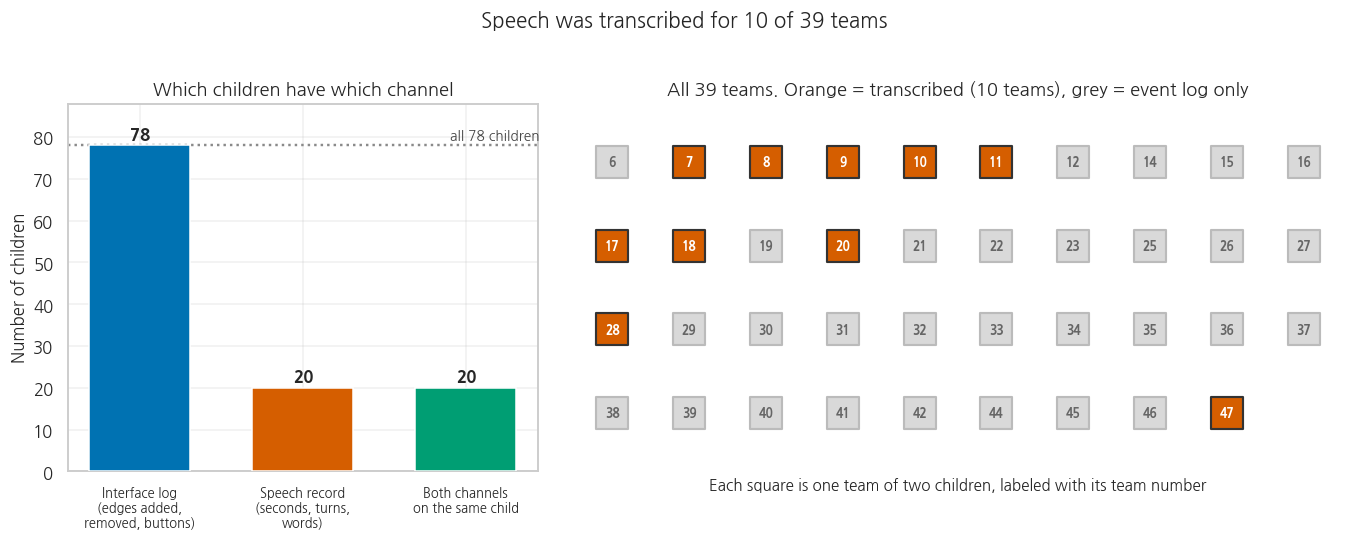

In [4]:
# --- one figure so the shape of the corpus is visible, not just described ------
fig, axes = plt.subplots(1, 2, figsize=(12.6, 4.8),
                         gridspec_kw={'width_ratios': [1, 1.7]})

ax = axes[0]
counts = [int(has_actions.sum()), int(has_speech.sum()), int((has_actions & has_speech).sum())]
labels = ['Interface log\n(edges added,\nremoved, buttons)', 'Speech record\n(seconds, turns,\nwords)', 'Both channels\non the same child']
bars = ax.bar(range(3), counts, color=[BLUE, ORANGE, GREEN], width=0.62, zorder=3)
ax.axhline(len(children), color=GREY, linestyle=':', linewidth=1.6, zorder=2)
ax.text(2.45, len(children) + 1.5, f'all {len(children)} children', ha='right', fontsize=9, color='#444444')
for b, c in zip(bars, counts):
    ax.text(b.get_x() + b.get_width() / 2, c + 1.5, str(c), ha='center', fontsize=11, fontweight='bold')
ax.set_xticks(range(3)); ax.set_xticklabels(labels, fontsize=8.5)
ax.set_ylabel('Number of children', fontsize=11)
ax.set_ylim(0, len(children) + 10)
ax.set_title('Which children have which channel', fontsize=12)

ax = axes[1]
teams = sorted(children['team_no'].unique())
transcribed = set(children.loc[has_speech, 'team_no'].unique())
ncol = 10
for i, t in enumerate(teams):
    r, c = divmod(i, ncol)
    is_t = t in transcribed
    ax.scatter(c, -r, s=460, marker='s',
               color=ORANGE if is_t else '#d9d9d9',
               edgecolors='#333333' if is_t else '#bbbbbb', linewidths=1.4, zorder=3)
    ax.text(c, -r, str(t), ha='center', va='center', fontsize=8,
            color='white' if is_t else '#666666', fontweight='bold', zorder=4)
ax.set_xlim(-0.7, ncol - 0.3); ax.set_ylim(-((len(teams) - 1) // ncol) - 0.7, 0.7)
ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
for s in ax.spines.values():
    s.set_visible(False)
ax.set_title(f'All {len(teams)} teams. Orange = transcribed ({len(transcribed)} teams), grey = event log only',
             fontsize=12)
ax.set_xlabel('Each square is one team of two children, labeled with its team number', fontsize=10)

fig.suptitle('Speech was transcribed for 10 of 39 teams',
             fontsize=13.5, y=1.02)
plt.show()

**Let's discuss.** In the right-hand panel, the transcribed teams are 7 to 11, 17, 18, 20, 28, and 47: mostly a run of consecutive early numbers, plus a few later ones.

One pattern worth noticing is that a run of early team numbers is something a research schedule can produce on its own. What are some plausible explanations for the selection, and which of them have nothing to do with the children? What additional information from the authors would help distinguish among them?

Then a second question for the memo. Given that the selection rule is not in the release and is unlikely to become available, what will you write about how far these ten teams can stand in for the thirty-nine?

---

## 2. Two records of the same session

For the twenty children with both channels, we now build the comparison.

**Why shares rather than raw counts.** One pair's recorded speech totals seven minutes and another's twenty-four. One pair's recorded interface actions total ninety-four and another's three hundred and twenty-six. Comparing a child's raw seconds against another team's raw seconds mostly compares the two sessions rather than the two children. So for each child we compute their **share of their own pair**:

$$\text{speech share} = \frac{\text{this child's seconds}}{\text{this child's seconds} + \text{their partner's seconds}}$$

A share of 0.50 means the two children split that channel evenly. A share of 0.75 means this child accounts for three quarters of it.

We do the same for interface actions, for words, and for edges added. Then we ask: **do these shares agree with each other?**

**Run the cell below.** It builds the share columns and prints all twenty children.

In [5]:
# The 20 children with both channels, and their share of their own pair.
both = children.dropna(subset=['speech_secs']).copy().reset_index(drop=True)

CHANNELS = ['speech_secs', 'words', 'turns', 'actions', 'adds', 'removes', 'presses']
NICE = {
    'speech_secs': 'speech seconds', 'words': 'words spoken', 'turns': 'speaking turns',
    'actions': 'interface actions', 'adds': 'edges added', 'removes': 'edges removed',
    'presses': 'button presses',
}
for c in CHANNELS:
    both['sh_' + c] = both[c] / both.groupby('team_no')[c].transform('sum')

show = both[['team_no', 'who', 'speech_secs', 'sh_speech_secs',
             'actions', 'sh_actions', 'words', 'sh_words', 'adds', 'sh_adds', 'gain']]
print(f'{len(both)} children in {both["team_no"].nunique()} pairs, both channels present\n')
print(show.round(3).to_string(index=False))

20 children in 10 pairs, both channels present

 team_no who  speech_secs  sh_speech_secs  actions  sh_actions  words  sh_words  adds  sh_adds  gain
       7   A      450.274           0.518      136       0.417 1468.0     0.462    96    0.505     0
       7   B      419.698           0.482      190       0.583 1711.0     0.538    94    0.495     2
       8   A      469.869           0.477       82       0.394 1455.0     0.438    54    0.562     1
       8   B      515.935           0.523      126       0.606 1864.0     0.562    42    0.438    -3
       9   A      543.847           0.382       85       0.425 1610.0     0.364    24    0.490     1
       9   B      881.183           0.618      115       0.575 2810.0     0.636    25    0.510     1
      10   A      221.261           0.337       73       0.316  613.0     0.300    49    0.462     2
      10   B      435.611           0.663      158       0.684 1432.0     0.700    57    0.538     2
      11   A      437.049           0.508  

### 2.1 Twenty rows are not twenty observations



Within a pair, the two shares **must sum to exactly 1**. If one child's speech share is 0.756, their partner's is 0.244, with no freedom left over. The second row of every pair carries no information the first row did not already carry: it is the first row reflected through the point (0.5, 0.5).

So a correlation computed across the twenty children is **not** a correlation with twenty independent observations in it. It has **ten** independent observations in it. Any p-value or interval that uses n = 20 will be too narrow, and the amount by which it is too narrow is not small.

**Run the cell below.** It computes the correlation the ordinary way on twenty children, then computes it again from the ten pair deviations alone, and checks that the two agree to six decimal places.

In [6]:
# Proof, not assertion. Both shares in a pair sum to 1, so the class mean of any
# share is exactly 0.5 and each pair contributes two mirrored points.
pair_sums = both.groupby('team_no')['sh_speech_secs'].sum()
print('Sum of the two speech shares within each pair (should be exactly 1.0):')
print('  ', sorted(pair_sums.round(12).unique()))
print(f"  mean speech share across all {len(both)} children = {both['sh_speech_secs'].mean():.12f}")
print()

r_20 = np.corrcoef(both['sh_speech_secs'], both['sh_actions'])[0, 1]

# The same quantity rebuilt from the 10 pairs: take child A of each pair, subtract
# 0.5 from each share, and correlate through the origin.
A = both[both['who'] == 'A'].set_index('team_no')
dx = A['sh_speech_secs'] - 0.5
dy = A['sh_actions'] - 0.5
r_10 = float((dx * dy).sum() / np.sqrt((dx ** 2).sum() * (dy ** 2).sum()))

print(f'  correlation computed on all {len(both)} children      : {r_20:.6f}')
print(f'  correlation rebuilt from the {len(A)} pair deviations : {r_10:.6f}')
print(f'  identical to 6 decimal places                  : {round(r_20, 6) == round(r_10, 6)}')
print()
print('  Effective sample size for anything built on these shares: '
      f'{len(A)} pairs, not {len(both)} children.')

Sum of the two speech shares within each pair (should be exactly 1.0):
   [1.0]
  mean speech share across all 20 children = 0.500000000000

  correlation computed on all 20 children      : 0.208291
  correlation rebuilt from the 10 pair deviations : 0.208291
  identical to 6 decimal places                  : True

  Effective sample size for anything built on these shares: 10 pairs, not 20 children.


That is why every interval below is a **cluster bootstrap**: whole pairs are resampled with replacement, never individual children. Resampling children would sometimes draw a child without their partner, which breaks the arithmetic that makes a share a share, and the resulting interval would be far too narrow.

Week 5 met the same structure in a different form: the spans inside one essay are not independent observations, which is why the interval there resampled essays rather than spans. It is the same issue with different nesting, and it is worth watching for in your own data, where the nesting is usually students inside classrooms inside schools.

In [7]:
def pair_bootstrap_r(df, x, y, team='team_no', B=4000, seed=SEED):
    '''Pearson r plus a 95% interval from resampling whole teams, not children.

    Returns (r, low, high). Resampling teams keeps both members of a pair
    together, which is the only way an interval on a share is honest.
    '''
    rng = np.random.default_rng(seed)
    df = df.reset_index(drop=True)
    tlist = df[team].unique()
    pos = {t: df.index[df[team] == t].to_numpy() for t in tlist}
    X, Y = df[x].to_numpy(), df[y].to_numpy()
    draws = []
    for _ in range(B):
        pick = rng.choice(len(tlist), len(tlist), replace=True)
        ii = np.concatenate([pos[tlist[p]] for p in pick])
        a, b = X[ii], Y[ii]
        if a.std() < 1e-12 or b.std() < 1e-12:
            continue
        draws.append(np.corrcoef(a, b)[0, 1])
    draws = np.asarray(draws)
    return (float(np.corrcoef(X, Y)[0, 1]),
            float(np.percentile(draws, 2.5)), float(np.percentile(draws, 97.5)))


pairs_of_interest = [('sh_speech_secs', 'sh_actions'), ('sh_words', 'sh_adds')]
results = {}
print(f'Cluster bootstrap, resampling {both["team_no"].nunique()} pairs, 4000 draws\n')
for x, y in pairs_of_interest:
    r, lo, hi = pair_bootstrap_r(both, x, y)
    results[(x, y)] = (r, lo, hi)
    print(f'  share of {NICE[x[3:]]:<18} vs share of {NICE[y[3:]]:<18}'
          f'  r = {r:+.3f}   95% CI [{lo:+.3f}, {hi:+.3f}]')

Cluster bootstrap, resampling 10 pairs, 4000 draws



  share of speech seconds     vs share of interface actions   r = +0.208   95% CI [-0.262, +0.697]


  share of words spoken       vs share of edges added         r = +0.015   95% CI [-0.659, +0.784]


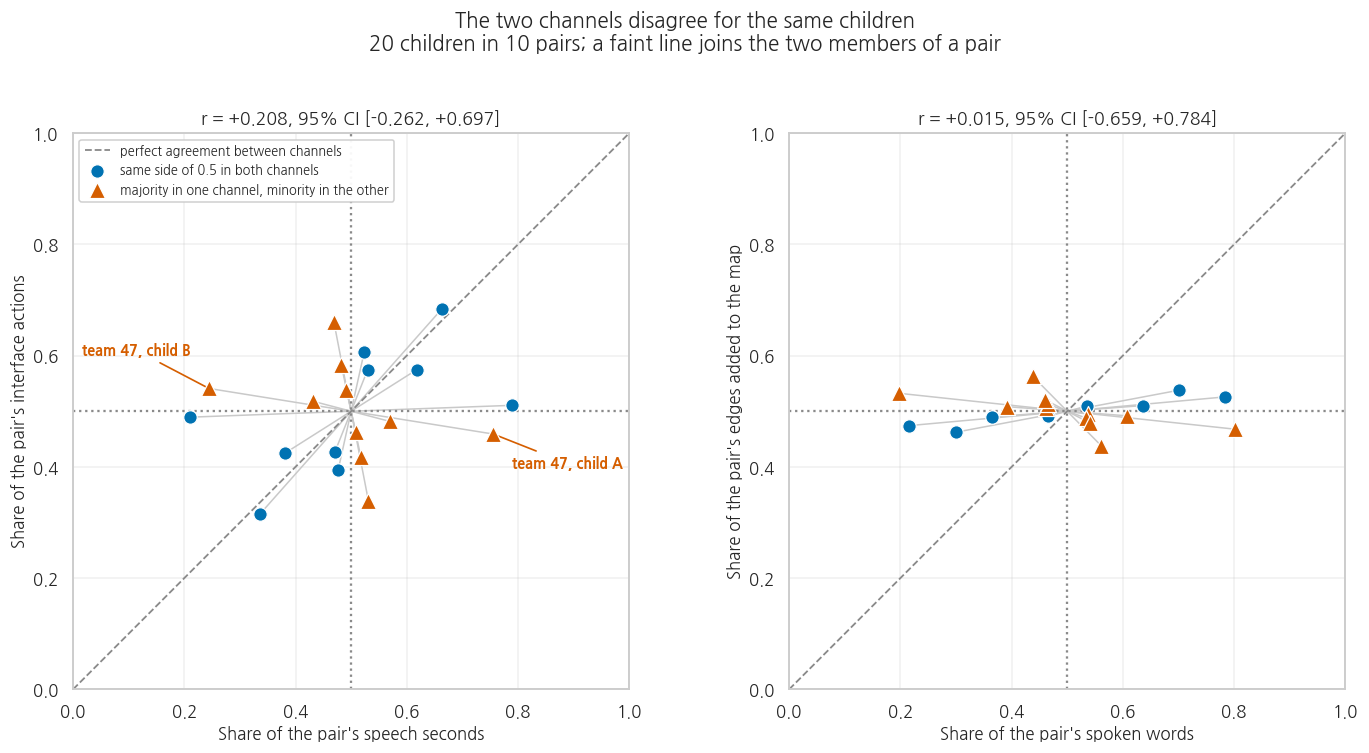

In [8]:
def share_scatter(ax, xcol, ycol, title):
    x, y = both[xcol], both[ycol]
    # join each pair with a faint line so the mirror structure is visible
    for t, g in both.groupby('team_no'):
        ax.plot(g[xcol], g[ycol], color='#c9c9c9', linewidth=1.0, zorder=1)
    ax.axhline(0.5, color=GREY, linestyle=':', linewidth=1.5, zorder=2)
    ax.axvline(0.5, color=GREY, linestyle=':', linewidth=1.5, zorder=2)
    ax.plot([0, 1], [0, 1], color=GREY, linestyle='--', linewidth=1.2, zorder=2,
            label='perfect agreement between channels')
    flip = (x > 0.5) != (y > 0.5)
    ax.scatter(x[~flip], y[~flip], s=78, color=BLUE, marker='o',
               edgecolors='white', linewidths=0.8, zorder=4,
               label='same side of 0.5 in both channels')
    ax.scatter(x[flip], y[flip], s=110, color=ORANGE, marker='^',
               edgecolors='white', linewidths=0.8, zorder=5,
               label='majority in one channel, minority in the other')
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_aspect('equal')
    ax.set_title(title, fontsize=11.5)
    return flip


fig, axes = plt.subplots(1, 2, figsize=(13.2, 6.4))

r1, lo1, hi1 = results[('sh_speech_secs', 'sh_actions')]
share_scatter(axes[0], 'sh_speech_secs', 'sh_actions',
              f'r = {r1:+.3f}, 95% CI [{lo1:+.3f}, {hi1:+.3f}]')
axes[0].set_xlabel("Share of the pair's speech seconds", fontsize=11)
axes[0].set_ylabel("Share of the pair's interface actions", fontsize=11)

t47 = both[both['team_no'] == 47]
for _, row in t47.iterrows():
    axes[0].annotate(f"team 47, child {row['who']}",
                     (row['sh_speech_secs'], row['sh_actions']),
                     xytext=(12 if row['who'] == 'A' else -12, -22 if row['who'] == 'A' else 22),
                     textcoords='offset points', fontsize=9.5, color=ORANGE, fontweight='bold',
                     ha='left' if row['who'] == 'A' else 'right',
                     arrowprops=dict(arrowstyle='-', color=ORANGE, linewidth=1.1))

r2, lo2, hi2 = results[('sh_words', 'sh_adds')]
share_scatter(axes[1], 'sh_words', 'sh_adds',
              f'r = {r2:+.3f}, 95% CI [{lo2:+.3f}, {hi2:+.3f}]')
axes[1].set_xlabel("Share of the pair's spoken words", fontsize=11)
axes[1].set_ylabel("Share of the pair's edges added to the map", fontsize=11)

axes[0].legend(loc='upper left', fontsize=8.4, framealpha=0.94)
fig.suptitle('The two channels disagree for the same children\n'
             f'{len(both)} children in {both["team_no"].nunique()} pairs; a faint line joins the two members of a pair',
             fontsize=13.5, y=1.045)
plt.show()

**Let's look at the output.**

The left panel says that a child's share of the pair's recorded speech seconds tells you little about their share of its recorded interface actions: **r = +0.21, with a 95% interval running from about -0.26 to +0.70.** The right panel is flatter still: word share against edge-add share comes out at **r = +0.015**, with an interval of roughly -0.66 to +0.78, which is wide enough that the result is best described as uninformative.

These are two different claims.

1. The **point estimate** is small. What would a dashboard that ranked these children on speaking time get right about their work on the map?
2. The **interval** is very wide. What does the interval alone rule out, and what does it leave open? A sentence beginning "With ten pairs, I cannot rule out ..." is a useful form here.

And a third for the memo. The diagonal line marks perfect agreement between the two channels, and it passes through almost none of the points. If the two channels were measuring the same underlying thing, where would the points be?

*Connecting to the readings.* Sharma and Giannakos (2020), in this week's additional readings, argue that different modalities capture different aspects of a learning situation, so combining them is a design decision rather than something that happens automatically once more sensors are added. This scatter is a small version of that: two channels recorded from the same twenty children in the same twenty sessions do not line up.

### Your turn 1: a different pair of channels

Every channel in `CHANNELS` has a `sh_` version. You might set `CHANNEL_X` and `CHANNEL_Y` below to any two of them and re-run. The defaults already work, so the notebook runs fine if you leave them alone.

Each of these asks a real question:

- `'turns'` against `'speech_secs'` asks whether taking many turns is the same as speaking for a long time. Two readings of one microphone, so strong agreement is what we would expect.
- `'presses'` against `'adds'` asks whether the child pressing the buttons is the child drawing the tracks.
- `'words'` against `'actions'` is the version of the headline comparison that a text analyst would run.

Share of speaking turns vs share of speech seconds
  across 20 children in 10 pairs
  Pearson r = +0.966   95% CI [+0.781, +0.994]  (bootstrap over pairs)

  The interval excludes zero. With ten pairs that is worth noticing, and
  it is still ten pairs, so report the interval and not just the r.


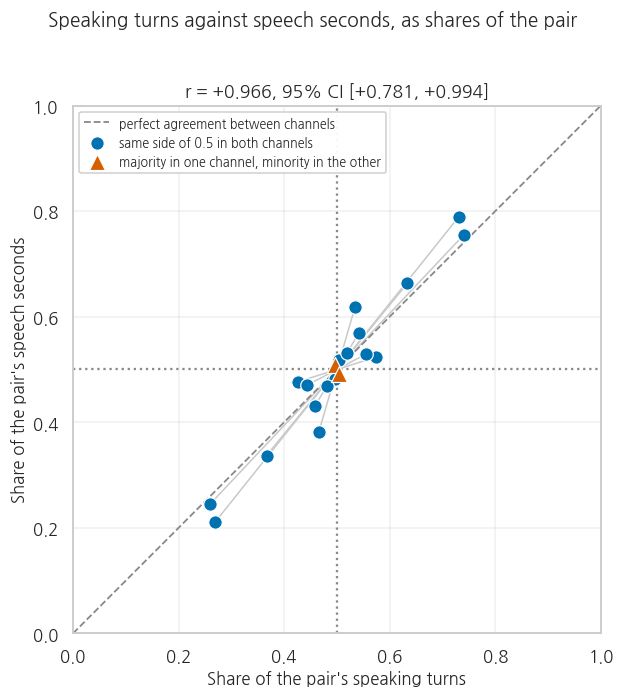

In [9]:
# TODO: change these two and re-run.
CHANNEL_X = 'turns'
CHANNEL_Y = 'speech_secs'

r, lo, hi = pair_bootstrap_r(both, 'sh_' + CHANNEL_X, 'sh_' + CHANNEL_Y)
print(f'Share of {NICE[CHANNEL_X]} vs share of {NICE[CHANNEL_Y]}')
print(f'  across {len(both)} children in {both["team_no"].nunique()} pairs')
print(f'  Pearson r = {r:+.3f}   95% CI [{lo:+.3f}, {hi:+.3f}]  (bootstrap over pairs)')
print()
if lo < 0 < hi:
    print('  The interval contains zero. This corpus cannot establish the direction')
    print('  of this relationship, which can be reported as a finding.')
else:
    print('  The interval excludes zero. With ten pairs that is worth noticing, and')
    print('  it is still ten pairs, so report the interval and not just the r.')

fig, ax = plt.subplots(figsize=(6.4, 6.2))
share_scatter(ax, 'sh_' + CHANNEL_X, 'sh_' + CHANNEL_Y,
              f'r = {r:+.3f}, 95% CI [{lo:+.3f}, {hi:+.3f}]')
ax.set_xlabel(f"Share of the pair's {NICE[CHANNEL_X]}", fontsize=11)
ax.set_ylabel(f"Share of the pair's {NICE[CHANNEL_Y]}", fontsize=11)
ax.legend(loc='upper left', fontsize=8.2, framealpha=0.94)
fig.suptitle(f'{NICE[CHANNEL_X].capitalize()} against {NICE[CHANNEL_Y]}, as shares of the pair',
             fontsize=12.5, y=1.02)
plt.show()

**Let's discuss.** It may be useful to note the correlation you got, the interval, and one sentence about the shape of the scatter rather than the number: are the points spread along the diagonal, spread along a horizontal band, or bunched near the middle with no direction at all?

Then, which of the two channels would you rather have if you were allowed only one? With ten pairs, that answer is a preference rather than a result, and saying so is part of the answer.

---

## 3. Counting the pairs that swap majority contributor between channels

The scatter shows the pattern; this section counts it.

Call a child the **majority contributor** in a channel if their share of that channel is above 0.5. Then ask: how many children are the majority contributor in one channel and the minority in the other?

One arithmetic point first. **A swap is a property of the pair, not of the child.** If child A is above 0.5 on speech and below 0.5 on actions, then child B is necessarily below on speech and above on actions. Both children of that pair swap, every time, by construction. So counting children double counts, and an interval computed on the child count will be too narrow.

We count pairs. **Run the cell below.**

In [10]:
from math import sqrt

both['swaps'] = (both['sh_speech_secs'] > 0.5) != (both['sh_actions'] > 0.5)
by_team = both.groupby('team_no')['swaps'].agg(['sum', 'any'])
print('Children who swap, per pair (always 0 or 2, never 1):')
print('  ', sorted(by_team['sum'].unique()))
print()

n_pairs = int(both['team_no'].nunique())
k_pairs = int(by_team['any'].sum())
n_kids, k_kids = len(both), int(both['swaps'].sum())


def wilson(k, n, z=1.96):
    '''Wilson score interval for a proportion. Behaves correctly at small n.'''
    if n == 0:
        return (0.0, 0.0)
    p = k / n
    denom = 1 + z ** 2 / n
    center = (p + z ** 2 / (2 * n)) / denom
    half = z * sqrt(p * (1 - p) / n + z ** 2 / (4 * n ** 2)) / denom
    return max(0.0, center - half), min(1.0, center + half)


lo_p, hi_p = wilson(k_pairs, n_pairs)
lo_c, hi_c = wilson(k_kids, n_kids)
print(f'CORRECT   : {k_pairs} of {n_pairs} pairs swap  = {k_pairs / n_pairs:.0%}'
      f'   95% CI [{lo_p:.0%}, {hi_p:.0%}]')
print(f'TEMPTING  : {k_kids} of {n_kids} children swap = {k_kids / n_kids:.0%}'
      f'   95% CI [{lo_c:.0%}, {hi_c:.0%}]  <- same estimate, interval too narrow')
print()
narrower = 1 - (hi_c - lo_c) / (hi_p - lo_p)
print(f'  Both estimates are 50%. The second interval is {narrower:.0%} narrower than the')
print('  first, and that difference comes entirely from')
print('  counting each pair twice.')
print()
print('Pairs that swap:', sorted(by_team.index[by_team['any']].tolist()))

Children who swap, per pair (always 0 or 2, never 1):
   [0, 2]

CORRECT   : 5 of 10 pairs swap  = 50%   95% CI [24%, 76%]
TEMPTING  : 10 of 20 children swap = 50%   95% CI [30%, 70%]  <- same estimate, interval too narrow

  Both estimates are 50%. The second interval is 24% narrower than the
  first, and that difference comes entirely from
  counting each pair twice.

Pairs that swap: [7, 11, 20, 28, 47]


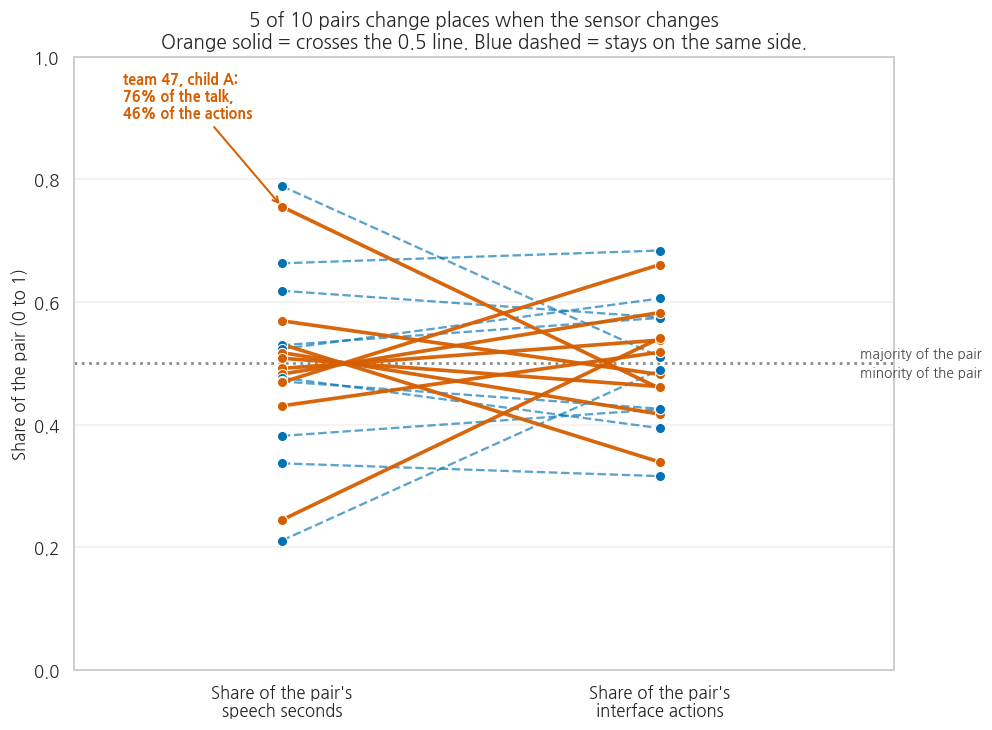

In [11]:
# A slopegraph. Each child is one line from their speech share to their action share.
order = both.sort_values('sh_speech_secs', ascending=False)

fig, ax = plt.subplots(figsize=(9.2, 6.8))
ax.axhline(0.5, color=GREY, linestyle=':', linewidth=1.8, zorder=2)
ax.text(1.53, 0.505, 'majority of the pair', fontsize=9, color='#444444', va='bottom')
ax.text(1.53, 0.495, 'minority of the pair', fontsize=9, color='#444444', va='top')

for _, row in order.iterrows():
    sw = row['swaps']
    ax.plot([0, 1], [row['sh_speech_secs'], row['sh_actions']],
            color=ORANGE if sw else BLUE,
            linestyle='-' if sw else '--',
            linewidth=2.4 if sw else 1.5,
            alpha=0.95 if sw else 0.65, zorder=4 if sw else 3)
    ax.scatter([0, 1], [row['sh_speech_secs'], row['sh_actions']],
               s=44, color=ORANGE if sw else BLUE, zorder=5,
               edgecolors='white', linewidths=0.7)

t47a = both[(both['team_no'] == 47) & (both['who'] == 'A')].iloc[0]
ax.annotate('team 47, child A:\n76% of the talk,\n46% of the actions',
            (0, t47a['sh_speech_secs']), xytext=(-0.42, 0.90), fontsize=9.5,
            color=ORANGE, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=ORANGE, linewidth=1.3))

ax.set_xlim(-0.55, 1.62); ax.set_ylim(0, 1)
ax.set_xticks([0, 1])
ax.set_xticklabels(["Share of the pair's\nspeech seconds",
                    "Share of the pair's\ninterface actions"], fontsize=11)
ax.set_ylabel('Share of the pair (0 to 1)', fontsize=11)
ax.grid(axis='x', visible=False)
ax.set_title(f'{k_pairs} of {n_pairs} pairs change places when the sensor changes\n'
             f'Orange solid = crosses the 0.5 line. Blue dashed = stays on the same side.',
             fontsize=12.5)
plt.show()

**Let's discuss.** Five of the ten pairs reverse. The 95% interval on that proportion runs from about **24% to 76%**, so we saw half, and ten pairs cannot narrow that much.

Suppose you are the instructor of these children and you have one number to work with.



Two things worth writing down. First: for the five swapping pairs, what would a participation judgment based on what you noticed during the session have recorded, and what would the interface log have recorded?

Second, one pattern worth noticing is that a child can contribute heavily on the map and lightly on the microphone. What are some plausible explanations that are about the situation rather than about the child? Who is sitting where, whose hand is on the input device, what the robot has just said, and what happens in a pair when one person starts narrating are all places to look. What additional information about the session would help distinguish among them?

### Your turn 2: does the disagreement survive a larger threshold?

A pair split 0.51 to 0.49 on speech and 0.49 to 0.51 on actions technically swaps, and nobody would notice it in a classroom.

So a harder question. For each pair, measure **how far apart the two channels are**: the gap between a child's speech share and their action share. Then count how many pairs have a gap bigger than some size.

You might set `GAP` below to any value between 0 and 0.5 and re-run. The default works, so the notebook runs fine if you leave it alone. If the finding disappears the moment you ask for a gap large enough to be noticed in a classroom, that is itself worth reporting.

In [12]:
# TODO: change this and re-run. Try 0.05, 0.10, 0.15, 0.20, 0.30.
GAP = 0.10

# One number per pair: how far apart the two channels put the same child.
one_per_pair = both[both['who'] == 'A'].set_index('team_no')
channel_gap = (one_per_pair['sh_speech_secs'] - one_per_pair['sh_actions']).abs()

print('How far apart the two channels put the same child, pair by pair:')
print(channel_gap.round(3).sort_values(ascending=False).to_string())
print()
print(f'{"gap of at least":>16} {"pairs":>10} {"of":>4} {"95% CI":>18}')
print('-' * 54)
for th in [0.05, 0.10, 0.15, 0.20, 0.30]:
    k = int((channel_gap > th).sum())
    l, h = wilson(k, n_pairs)
    mark = '   <- your setting' if abs(th - GAP) < 1e-9 else ''
    print(f'{th:>16.2f} {k:>10} {n_pairs:>4}   [{l:>4.0%}, {h:>4.0%}]{mark}')
print()
print('Read the whole column rather than one row. The count falls as the threshold')
print('rises, by construction. The question is whether')
print('the disagreement is still there at a gap large enough to matter, and whether')
print('the interval on any single row is narrow enough to quote on its own.')

How far apart the two channels put the same child, pair by pair:
team_no
47    0.297
17    0.278
20    0.192
7     0.100
28    0.088
8     0.082
11    0.046
18    0.045
9     0.043
10    0.021

 gap of at least      pairs   of             95% CI
------------------------------------------------------
            0.05          6   10   [ 31%,  83%]
            0.10          4   10   [ 17%,  69%]   <- your setting
            0.15          3   10   [ 11%,  60%]
            0.20          2   10   [  6%,  51%]
            0.30          0   10   [  0%,  28%]

Read the whole column rather than one row. The count falls as the threshold
rises, by construction. The question is whether
the disagreement is still there at a gap large enough to matter, and whether
the interval on any single row is narrow enough to quote on its own.


---

## 4. Team 47

Team 47's two children were together for about twenty minutes.

**Run the cell below**, then the figure cell after it.

In [13]:
t47 = both[both['team_no'] == 47].copy()
kid_a, kid_b = t47.iloc[0], t47.iloc[1]

print('TEAM 47, the two children\n')
rows = [('speech seconds', 'speech_secs', '{:.0f} s'),
        ('words spoken', 'words', '{:.0f}'),
        ('speaking turns', 'turns', '{:.0f}'),
        ('interface actions', 'actions', '{:.0f}'),
        ('edges added', 'adds', '{:.0f}'),
        ('button presses', 'presses', '{:.0f}')]
print(f'{"channel":>20} {"child A":>12} {"child B":>12} {"A share":>10}')
print('-' * 58)
for label, col, fmt in rows:
    sa, sb = kid_a[col], kid_b[col]
    print(f'{label:>20} {fmt.format(sa):>12} {fmt.format(sb):>12} {sa / (sa + sb):>9.1%}')
print('-' * 58)
print(f'{"pre-test (of 10)":>20} {kid_a["score_pre"]:>12.0f} {kid_b["score_pre"]:>12.0f}')
print(f'{"post-test (of 10)":>20} {kid_a["score_post"]:>12.0f} {kid_b["score_post"]:>12.0f}')
print(f'{"gain":>20} {kid_a["gain"]:>+12.0f} {kid_b["gain"]:>+12.0f}')
print()
print(f'  Child A accounts for {kid_a["sh_speech_secs"]:.1%} of the pair\'s recorded speech seconds '
      f'({kid_a["speech_secs"]:.0f} s against {kid_b["speech_secs"]:.0f} s)')
print(f'  and {kid_a["sh_words"]:.1%} of its words ({kid_a["words"]:.0f} against {kid_b["words"]:.0f}),')
print(f'  but only {kid_a["sh_actions"]:.1%} of its interface actions '
      f'({kid_a["actions"]:.0f} against {kid_b["actions"]:.0f}).')
print(f'  Both children moved from {kid_a["score_pre"]:.0f} and {kid_b["score_pre"]:.0f} '
      f'to {kid_a["score_post"]:.0f} and {kid_b["score_post"]:.0f}: a gain of '
      f'{kid_a["gain"]:+.0f} each.')

TEAM 47, the two children

             channel      child A      child B    A share
----------------------------------------------------------
      speech seconds        505 s        163 s     75.6%
        words spoken         1745          480     78.4%
      speaking turns          263           92     74.1%
   interface actions           84           99     45.9%
         edges added           61           55     52.6%
      button presses           17           37     31.5%
----------------------------------------------------------
    pre-test (of 10)            9            7
   post-test (of 10)            8            6
                gain           -1           -1

  Child A accounts for 75.6% of the pair's recorded speech seconds (505 s against 163 s)
  and 78.4% of its words (1745 against 480),
  but only 45.9% of its interface actions (84 against 99).
  Both children moved from 9 and 7 to 8 and 6: a gain of -1 each.


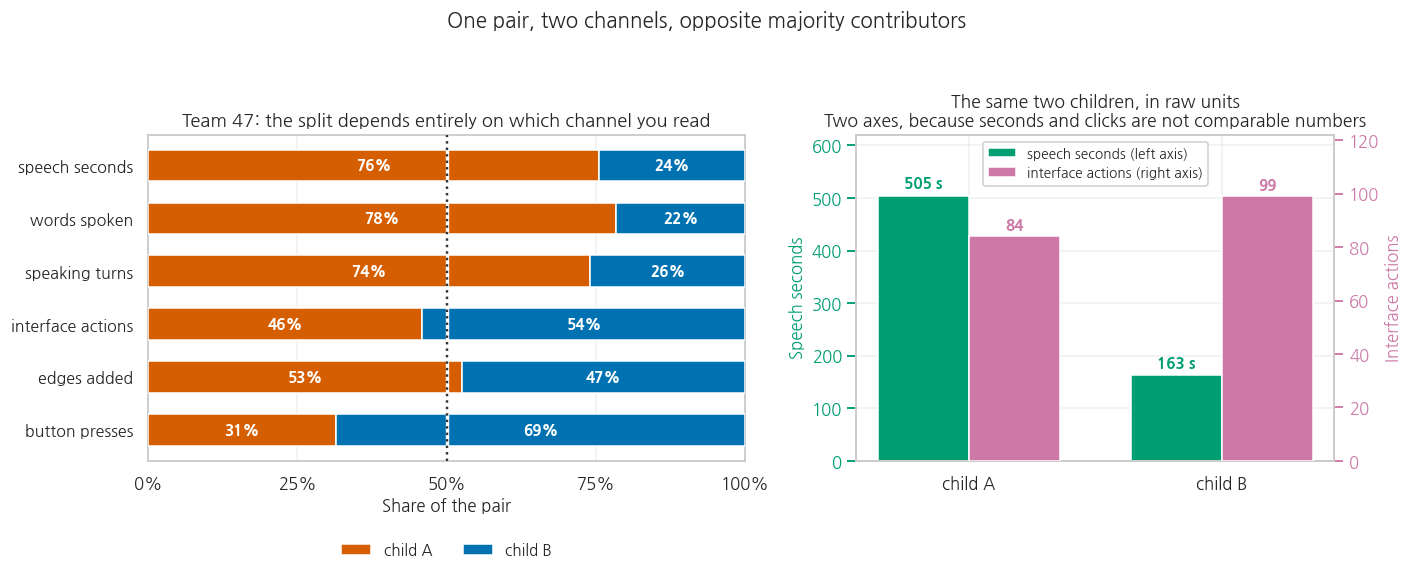

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13.0, 5.4),
                         gridspec_kw={'width_ratios': [1.25, 1]})

# --- panel 1: shares, side by side ------------------------------------------
ax = axes[0]
chans = ['speech_secs', 'words', 'turns', 'actions', 'adds', 'presses']
ypos = np.arange(len(chans))[::-1]
a_share = [kid_a['sh_' + c] for c in chans]
ax.barh(ypos, a_share, color=ORANGE, height=0.6, zorder=3, label='child A')
ax.barh(ypos, [1 - s for s in a_share], left=a_share, color=BLUE, height=0.6,
        zorder=3, label='child B')
ax.axvline(0.5, color='white', linewidth=2.2, zorder=4)
ax.axvline(0.5, color='#333333', linestyle=':', linewidth=1.6, zorder=5)
for yy, c, s in zip(ypos, chans, a_share):
    ax.text(s / 2, yy, f'{s:.0%}', ha='center', va='center', color='white',
            fontsize=10, fontweight='bold', zorder=6)
    ax.text(s + (1 - s) / 2, yy, f'{1 - s:.0%}', ha='center', va='center', color='white',
            fontsize=10, fontweight='bold', zorder=6)
ax.set_yticks(ypos); ax.set_yticklabels([NICE[c] for c in chans], fontsize=10.5)
ax.set_xlim(0, 1); ax.set_xlabel('Share of the pair', fontsize=11)
ax.set_xticks([0, 0.25, 0.5, 0.75, 1])
ax.set_xticklabels(['0%', '25%', '50%', '75%', '100%'])
ax.grid(axis='y', visible=False)
ax.legend(loc='lower center', bbox_to_anchor=(0.5, -0.34), ncol=2, fontsize=10, frameon=False)
ax.set_title('Team 47: the split depends entirely on which channel you read',
             fontsize=12)

# --- panel 2: raw seconds and raw actions ------------------------------------
ax = axes[1]
x = np.arange(2)
w = 0.36
sp = [kid_a['speech_secs'], kid_b['speech_secs']]
ac = [kid_a['actions'], kid_b['actions']]
b1 = ax.bar(x - w / 2, sp, w, color=GREEN, zorder=3, label='speech seconds (left axis)')
ax.set_ylabel('Speech seconds', fontsize=11, color=GREEN)
ax.tick_params(axis='y', colors=GREEN)
ax.set_ylim(0, 620)
for xx, v in zip(x - w / 2, sp):
    ax.text(xx, v + 14, f'{v:.0f} s', ha='center', fontsize=10, fontweight='bold', color=GREEN)

ax2 = ax.twinx()
b2 = ax2.bar(x + w / 2, ac, w, color=PURPLE, zorder=3, label='interface actions (right axis)')
ax2.set_ylabel('Interface actions', fontsize=11, color=PURPLE)
ax2.tick_params(axis='y', colors=PURPLE)
ax2.set_ylim(0, 122)
ax2.grid(False)
for xx, v in zip(x + w / 2, ac):
    ax2.text(xx, v + 2.5, f'{v:.0f}', ha='center', fontsize=10, fontweight='bold', color=PURPLE)

ax.set_xticks(x); ax.set_xticklabels(['child A', 'child B'], fontsize=11)
ax.set_title('The same two children, in raw units\n'
             'Two axes, because seconds and clicks are not comparable numbers',
             fontsize=11.5)
ax.legend(handles=[b1, b2], loc='upper center', fontsize=9, framealpha=0.94)

fig.suptitle('One pair, two channels, opposite majority contributors', fontsize=13.5, y=1.04)
plt.show()

**Let's look at the output.**

Child A's recorded speech is **505 seconds against child B's 163**, 76% of the pair's recorded speech seconds and 78% of its transcribed words. The event log records **84 interface actions for child A against 99 for child B**, 46% of the pair's total. Both children scored one point lower after the session than before.

Three things to write down.

1. If you had been observing that session, which child would you have recorded as the active participant? Which channel were you using to decide?
2. The two children ended with the same gain. What does that do to a claim that either channel measured who gained on the test?
3. One pattern worth noticing is a child who holds most of the talk and less than half of the interface actions. What are some plausible explanations, and which of them are about the situation rather than about the children's dispositions? Who is holding the mouse, what a pair does when one person becomes the narrator and the other the operator, and how a transcript treats a child who speaks quietly or in short overlapping bursts are three places to start. What additional information would help distinguish among them?

---

## 5. The change in test score

We have seen that the two channels disagree about who participated. The next question is whether either channel is associated with the change in test score.

The outcome is examined before anything is correlated with it. An outcome variable with almost no variance, or one whose average change is indistinguishable from zero, will not support strong claims however good the predictor.

**Run the cell below.**

In [15]:
g = children['gain']
print('LEARNING GAIN: post-test minus pre-test, on a 10-item test\n')
print(f'  pre-test  mean {children["score_pre"].mean():.2f}  (sd {children["score_pre"].std():.2f})')
print(f'  post-test mean {children["score_post"].mean():.2f}  (sd {children["score_post"].std():.2f})')
print(f'  gain      mean {g.mean():+.3f}  (sd {g.std():.3f}), range {g.min():+.0f} to {g.max():+.0f}')
print()
print('  Distribution of gain across all 78 children:')
for v, n in g.value_counts().sort_index().items():
    print(f'    {v:+d} points : {"#" * n} ({n})')
print()
print(f'  scored higher after : {(g > 0).sum():>2} children ({(g > 0).mean():.0%})')
print(f'  scored the same     : {(g == 0).sum():>2} children ({(g == 0).mean():.0%})')
print(f'  scored lower after  : {(g < 0).sum():>2} children ({(g < 0).mean():.0%})')
print()


def pair_bootstrap_mean(df, col, team='team_no', B=4000, seed=SEED):
    rng = np.random.default_rng(seed)
    df = df.reset_index(drop=True)
    tlist = df[team].unique()
    pos = {t: df.index[df[team] == t].to_numpy() for t in tlist}
    V = df[col].to_numpy()
    draws = [V[np.concatenate([pos[tlist[p]] for p in
                               rng.choice(len(tlist), len(tlist), True)])].mean()
             for _ in range(B)]
    return float(V.mean()), float(np.percentile(draws, 2.5)), float(np.percentile(draws, 97.5))


m, lo, hi = pair_bootstrap_mean(children, 'gain')
print(f'  Mean gain {m:+.3f} points, 95% CI [{lo:+.3f}, {hi:+.3f}] (bootstrap over 39 pairs)')
print()
print('  The interval contains zero. On this test, the mean change from pre to post is')
print('  not distinguishable from zero. That is a fact about a 10-item test taken twice')
print('  by a child aged 9 to 12 as much as it is a fact about the activity, and it')
print('  limits everything that follows in this section.')

LEARNING GAIN: post-test minus pre-test, on a 10-item test

  pre-test  mean 5.85  (sd 1.56)
  post-test mean 5.95  (sd 1.60)
  gain      mean +0.103  (sd 1.465), range -3 to +3

  Distribution of gain across all 78 children:
    -3 points : ##### (5)
    -2 points : ###### (6)
    -1 points : ############ (12)
    +0 points : ######################## (24)
    +1 points : ################## (18)
    +2 points : ########## (10)
    +3 points : ### (3)

  scored higher after : 31 children (40%)
  scored the same     : 24 children (31%)
  scored lower after  : 23 children (29%)



  Mean gain +0.103 points, 95% CI [-0.244, +0.436] (bootstrap over 39 pairs)

  The interval contains zero. On this test, the mean change from pre to post is
  not distinguishable from zero. That is a fact about a 10-item test taken twice
  by a child aged 9 to 12 as much as it is a fact about the activity, and it
  limits everything that follows in this section.


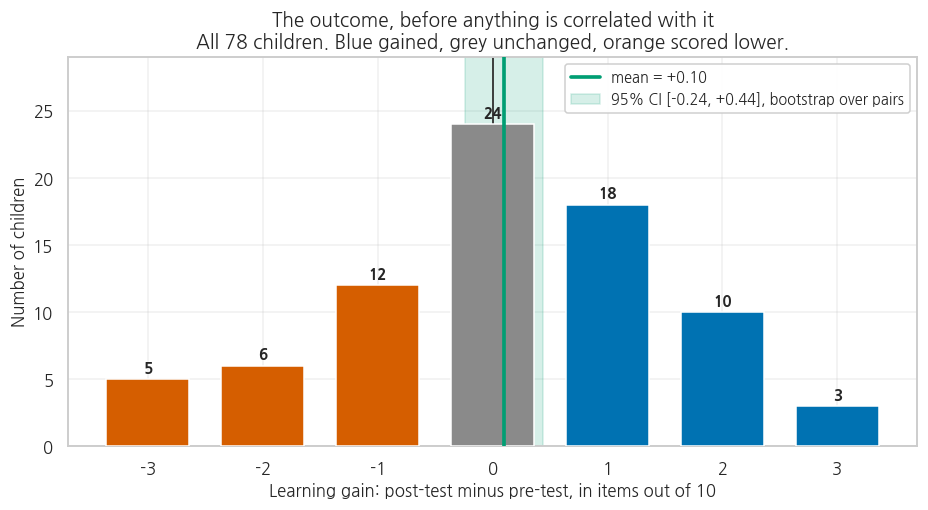

In [16]:
fig, ax = plt.subplots(figsize=(8.6, 4.8))
vals = sorted(g.unique())
counts = [int((g == v).sum()) for v in vals]
cols = [BLUE if v > 0 else (GREY if v == 0 else ORANGE) for v in vals]
bars = ax.bar(vals, counts, color=cols, width=0.72, zorder=3, edgecolor='white', linewidth=1.0)
for v, c in zip(vals, counts):
    ax.text(v, c + 0.5, str(c), ha='center', fontsize=10, fontweight='bold')
ax.axvline(0, color='#333333', linewidth=1.2, zorder=2)
ax.axvline(m, color=GREEN, linewidth=2.4, zorder=4, label=f'mean = {m:+.2f}')
ax.axvspan(lo, hi, color=GREEN, alpha=0.16, zorder=1,
           label=f'95% CI [{lo:+.2f}, {hi:+.2f}], bootstrap over pairs')
ax.set_xlabel('Learning gain: post-test minus pre-test, in items out of 10', fontsize=11)
ax.set_ylabel('Number of children', fontsize=11)
ax.set_xticks(vals)
ax.set_ylim(0, max(counts) + 5)
ax.legend(fontsize=9.5, framealpha=0.94)
ax.set_title(f'The outcome, before anything is correlated with it\n'
             f'All {len(children)} children. Blue gained, grey unchanged, orange scored lower.',
             fontsize=12.5)
plt.show()

**Let's discuss.** Twenty-three children out of seventy-eight scored **lower** after the activity than before.

One pattern worth noticing is a substantial group of negative gains on a short test taken twice. What are some plausible explanations? Candidates include what a 10-item test does when a child guesses, what happens to test-retest scores when the retest comes at the end of a long session, and what a pre-test does for a child meeting the idea for the first time. What additional information would help distinguish among them?


It may be worth having those explanations ready for the memo.


### 5.1 Which channel is associated with gain?

Now the comparison, on the same twenty children and the same outcome, with two predictors:

- the child's **speech seconds** and their **speech share** of the pair, and
- the child's **count of interface actions**.

Both get a cluster bootstrap interval over pairs. We report Spearman beside Pearson, because counts like these are usually right-skewed.

**Run the cell below.**

In [17]:
from scipy.stats import spearmanr

print(f'Correlations with individual learning gain, {len(both)} children in {both["team_no"].nunique()} pairs\n')
print(f'{"predictor":<32} {"Pearson r":>10} {"95% CI":>20} {"Spearman":>10}')
print('-' * 76)
for col, label in [('speech_secs', 'speech seconds'),
                   ('words', 'words spoken'),
                   ('turns', 'speaking turns'),
                   ('actions', 'interface actions'),
                   ('adds', 'edges added')]:
    r, lo, hi = pair_bootstrap_r(both, col, 'gain')
    rho = spearmanr(both[col], both['gain']).statistic
    print(f'{label:<32} {r:>+10.3f} {f"[{lo:+.2f}, {hi:+.2f}]":>20} {rho:>+10.3f}')

# The share version is reported without an interval, on purpose. See the note.
r_share = float(np.corrcoef(both['sh_speech_secs'], both['gain'])[0, 1])
print(f'{"share of the pair" + chr(39) + "s speech":<32} {r_share:>+10.3f} '
      f'{"see note below":>20} '
      f'{spearmanr(both["sh_speech_secs"], both["gain"]).statistic:>+10.3f}')
print()
print('  Why the last row has no interval. Because the two shares in a pair sum to 1,')
print('  a correlation between a share and an individual outcome is determined')
print('  arithmetically by within-pair DIFFERENCES in that outcome, and only five of the ten')
print('  pairs differ in gain at all. A bootstrap on it comes back deceptively narrow.')
print('  The direct version of that comparison is more informative, and it is in the')
print('  solutions appendix: of the five pairs whose children gained different amounts,')
print('  the child who spoke more gained more in zero of them (exact sign test p = 0.06).')
print('  Five comparisons pointing the same way is worth noticing and is not a finding.')
print()
print('And the interface log on ALL 78 children, where speech is unavailable but')
print('the event log is complete:')
r78, lo78, hi78 = pair_bootstrap_r(children, 'actions', 'gain')
print(f'  interface actions ~ gain, n = {len(children)} children in '
      f'{children["team_no"].nunique()} pairs: r = {r78:+.3f}, 95% CI [{lo78:+.3f}, {hi78:+.3f}]')


def pair_bootstrap_r_diff(df, x1, x2, y, team='team_no', B=4000, seed=SEED):
    '''Interval on the DIFFERENCE between two correlations measured on the same children.

    Two correlations printed side by side are not a comparison. The comparison is
    the gap between them, and the gap has its own uncertainty, which is smaller
    than you would get by treating the two as independent because both are
    computed on the same twenty children. So we resample whole pairs once and
    recompute both correlations inside each draw.
    '''
    rng = np.random.default_rng(seed)
    d = df.reset_index(drop=True)
    tlist = d[team].unique()
    pos = {t: d.index[d[team] == t].to_numpy() for t in tlist}
    X1, X2, Y = d[x1].to_numpy(), d[x2].to_numpy(), d[y].to_numpy()
    obs = np.corrcoef(X1, Y)[0, 1] - np.corrcoef(X2, Y)[0, 1]
    draws = []
    for _ in range(B):
        pick = rng.choice(len(tlist), len(tlist), replace=True)
        ii = np.concatenate([pos[tlist[p]] for p in pick])
        if min(X1[ii].std(), X2[ii].std(), Y[ii].std()) < 1e-12:
            continue
        draws.append(np.corrcoef(X1[ii], Y[ii])[0, 1] - np.corrcoef(X2[ii], Y[ii])[0, 1])
    draws = np.asarray(draws)
    return (float(obs), float(np.percentile(draws, 2.5)), float(np.percentile(draws, 97.5)))


print()
print('THE COMPARISON ITSELF, which is what the comparison is about:')
d_ac, d_lo, d_hi = pair_bootstrap_r_diff(both, 'actions', 'speech_secs', 'gain')
print(f'  r(actions, gain) minus r(speech seconds, gain) = {d_ac:+.3f}, '
      f'95% CI [{d_lo:+.3f}, {d_hi:+.3f}]')
print('  The gap between the two channels is what the two point estimates suggest, and with ten pairs its')
print('  own interval contains zero. So "one channel carries more than the other" is a')
print('  point estimate rather than a result. Both belong in the memo together.')

Correlations with individual learning gain, 20 children in 10 pairs

predictor                         Pearson r               95% CI   Spearman
----------------------------------------------------------------------------


speech seconds                       +0.015       [-0.36, +0.35]     +0.039


words spoken                         +0.136       [-0.34, +0.55]     +0.104


speaking turns                       +0.085       [-0.42, +0.54]     +0.179


interface actions                    +0.404       [-0.13, +0.79]     +0.391


edges added                          +0.380       [-0.05, +0.72]     +0.414
share of the pair's speech           -0.089       see note below     -0.155

  Why the last row has no interval. Because the two shares in a pair sum to 1,
  a correlation between a share and an individual outcome is determined
  arithmetically by within-pair DIFFERENCES in that outcome, and only five of the ten
  pairs differ in gain at all. A bootstrap on it comes back deceptively narrow.
  The direct version of that comparison is more informative, and it is in the
  solutions appendix: of the five pairs whose children gained different amounts,
  the child who spoke more gained more in zero of them (exact sign test p = 0.06).
  Five comparisons pointing the same way is worth noticing and is not a finding.

And the interface log on ALL 78 children, where speech is unavailable but
the event log is complete:


  interface actions ~ gain, n = 78 children in 39 pairs: r = +0.170, 95% CI [-0.085, +0.392]

THE COMPARISON ITSELF, which is what the comparison is about:


  r(actions, gain) minus r(speech seconds, gain) = +0.388, 95% CI [-0.039, +0.707]
  The gap between the two channels is what the two point estimates suggest, and with ten pairs its
  own interval contains zero. So "one channel carries more than the other" is a
  point estimate rather than a result. Both belong in the memo together.


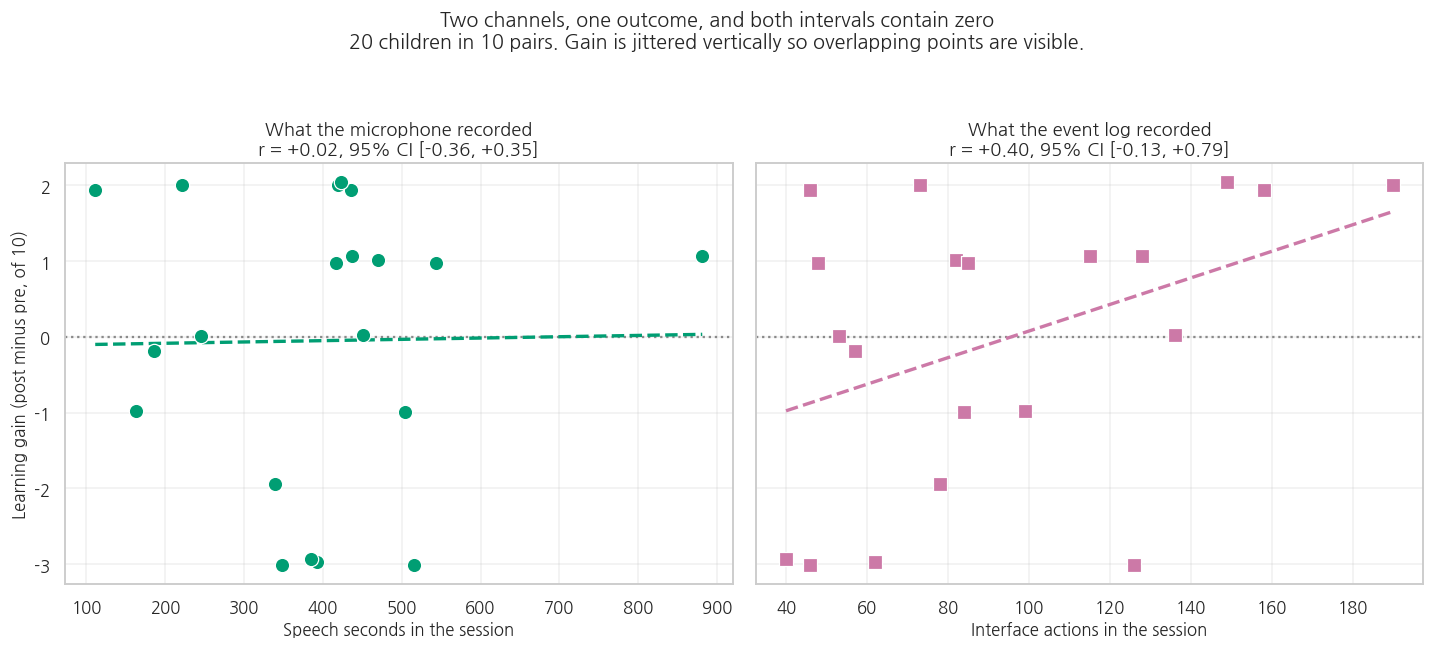

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13.2, 5.6), sharey=True)

jitter = np.random.default_rng(SEED).normal(0, 0.06, len(both))

r_sp, lo_sp, hi_sp = pair_bootstrap_r(both, 'speech_secs', 'gain')
ax = axes[0]
ax.scatter(both['speech_secs'], both['gain'] + jitter, s=88, color=GREEN, marker='o',
           edgecolors='white', linewidths=0.8, zorder=4)
z = np.polyfit(both['speech_secs'], both['gain'], 1)
xs = np.linspace(both['speech_secs'].min(), both['speech_secs'].max(), 50)
ax.plot(xs, np.polyval(z, xs), color=GREEN, linewidth=2.2, linestyle='--', zorder=3)
ax.axhline(0, color=GREY, linestyle=':', linewidth=1.5, zorder=2)
ax.set_xlabel('Speech seconds in the session', fontsize=11)
ax.set_ylabel('Learning gain (post minus pre, of 10)', fontsize=11)
ax.set_title(f'What the microphone recorded\nr = {r_sp:+.2f}, 95% CI [{lo_sp:+.2f}, {hi_sp:+.2f}]',
             fontsize=12)

r_ac, lo_ac, hi_ac = pair_bootstrap_r(both, 'actions', 'gain')
ax = axes[1]
ax.scatter(both['actions'], both['gain'] + jitter, s=88, color=PURPLE, marker='s',
           edgecolors='white', linewidths=0.8, zorder=4)
z = np.polyfit(both['actions'], both['gain'], 1)
xs = np.linspace(both['actions'].min(), both['actions'].max(), 50)
ax.plot(xs, np.polyval(z, xs), color=PURPLE, linewidth=2.2, linestyle='--', zorder=3)
ax.axhline(0, color=GREY, linestyle=':', linewidth=1.5, zorder=2)
ax.set_xlabel('Interface actions in the session', fontsize=11)
ax.set_title(f'What the event log recorded\nr = {r_ac:+.2f}, 95% CI [{lo_ac:+.2f}, {hi_ac:+.2f}]',
             fontsize=12)

fig.suptitle('Two channels, one outcome, and both intervals contain zero\n'
             f'{len(both)} children in {both["team_no"].nunique()} pairs. Gain is jittered vertically so overlapping points are visible.',
             fontsize=13, y=1.05)
plt.show()

**Let's look at the output.** Speech seconds against gain: **r = +0.015**. Speech share against gain: **r = -0.089**. Interface actions against gain: **r = +0.40**.

That contrast invites a headline, namely that the channel an instructor would instinctively grade is the one carrying no signal. Before writing it down, it is worth reading all three intervals, including the third one the cell prints.

1. Speech seconds against gain, **95% CI about -0.36 to +0.35**. Wide, and centered on nothing. "No detectable relationship" is what these data support; "no relationship" is not.
2. Interface actions against gain, **95% CI about -0.13 to +0.79**. This contains zero as well, so "interface actions carry a signal" is not established here either.
3. The gap between the two, **+0.39, with an interval from about -0.04 to +0.71**. Ten pairs cannot establish that one channel outperforms the other, even though the point estimates look very different.

One sentence stating the point estimates and one sentence stating what the intervals permit are worth writing separately, because the second is a different claim rather than a hedge on the first. What this section supports is narrower and more useful: **neither channel, at this sample size, licenses a statement about who gained on the test**, and the channel a teacher would trust most is not the one with the larger point estimate.



### 5.2 Between pairs and within pairs



The twenty children sit in ten pairs. Children in the same pair worked on **the same map**, with **the same robot**, for **the same length of time**. So their action counts are related to each other before any analysis, and so are their gains. The technical name for how much is the **intraclass correlation**.

When rows are nested like this, a child-level correlation can be produced in two completely different ways:

- **Between pairs.** Pairs with more recorded interface actions have higher mean gains. This is a claim about pairs.
- **Within pairs.** Inside a pair, the child with more recorded actions gained more than their partner. **This, and only this, is a claim about individuals**, and it is the one a participation grade would need.

They are separate quantities and they can point in opposite directions, so the cell computes both.

**Run the cell below.**

In [19]:
def icc1(df, value, group):
    '''One-way ICC: the share of a variable's variance that is between groups.

    0 means group membership tells you nothing. 1 means the two members of a pair
    are identical on this variable.
    '''
    grp = df.groupby(group)[value]
    n_groups, k = grp.ngroups, grp.size().mean()
    grand = df[value].mean()
    ms_between = (grp.size() * (grp.mean() - grand) ** 2).sum() / (n_groups - 1)
    within = df[value] - df.groupby(group)[value].transform('mean')
    ms_within = (within ** 2).sum() / (len(df) - n_groups)
    return (ms_between - ms_within) / (ms_between + (k - 1) * ms_within)


print('How much of each variable lives BETWEEN pairs rather than within them?\n')
for col, lab, df in [('actions', 'interface actions', children),
                     ('gain', 'learning gain', children),
                     ('score_pre', 'pre-test score', children),
                     ('speech_secs', 'speech seconds', both)]:
    print(f'  ICC of {lab:<20} = {icc1(df, col, "team_no"):+.3f}   (n = {len(df)} children)')
print()
print('  Interface actions: about half the variance is between pairs, which is consistent')
print('  with two children sharing one map: a pair that makes 300 moves gives both of')
print('  its members a high count. Pre-test score: essentially zero, so two members of a')
print('  pair are no more alike on the pre-test than two children drawn at random.')
print()
print('=' * 74)
print('DECOMPOSING the actions-and-gain relationship')
print('=' * 74)

for df, lab in [(both, f'{len(both)} children with both channels'),
                (children, f'all {len(children)} children')]:
    d = df.copy()
    d['team_mean_actions'] = d.groupby('team_no')['actions'].transform('mean')
    d['team_mean_gain'] = d.groupby('team_no')['gain'].transform('mean')
    tm = d.groupby('team_no').agg(a=('actions', 'mean'), g=('gain', 'mean'))
    r_child = np.corrcoef(d['actions'], d['gain'])[0, 1]
    r_between = np.corrcoef(tm['a'], tm['g'])[0, 1]
    wa = d['actions'] - d['team_mean_actions']
    wg = d['gain'] - d['team_mean_gain']
    r_within = np.corrcoef(wa, wg)[0, 1]
    print(f'\n{lab}, {d["team_no"].nunique()} pairs')
    print(f'  child level, ignoring the nesting        r = {r_child:+.3f}')
    print(f'  BETWEEN pairs (pair mean vs pair mean)   r = {r_between:+.3f}')
    print(f'  WITHIN pairs (deviation vs deviation)    r = {r_within:+.3f}')


def fisher_ci(r, n, z=1.96):
    zz = np.arctanh(r)
    se = 1 / np.sqrt(n - 3)
    return float(np.tanh(zz - z * se)), float(np.tanh(zz + z * se))


tm39 = children.groupby('team_no').agg(a=('actions', 'mean'), g=('gain', 'mean'))
r39 = np.corrcoef(tm39['a'], tm39['g'])[0, 1]
lo39, hi39 = fisher_ci(r39, len(tm39))
print()
print(f'The between-pair claim on all {len(tm39)} pairs, which is the largest sample we have:')
print(f'  pair mean actions ~ pair mean gain   r = {r39:+.3f}, 95% CI [{lo39:+.3f}, {hi39:+.3f}]')
print('  Rows here are 39 independent pairs, so an ordinary Fisher z interval is used; it')
print('  assumes approximate bivariate normality, which a mean of two integer scores meets only roughly.')


def within_pair_r(df, x, y, team='team_no', who='who', B=4000, seed=SEED):
    '''Within-pair correlation with an interval, resampling whole pairs.

    A within-pair number needs an interval as much as any other number, and it is
    the one people forget, because "no relationship inside pairs" sounds like a
    fact rather than an estimate.

    In a team of two, each child's deviation from the pair mean is exactly half
    the difference between the two children. So the within-pair correlation across
    all the children equals the correlation of the PAIR DIFFERENCES through the
    origin, and the effective sample size is the number of pairs, not children.
    That identity is also what makes the interval easy: resample pairs, recompute.
    '''
    a = df[df[who] == 'A'].set_index(team).sort_index()
    b = df[df[who] == 'B'].set_index(team).sort_index()
    dx = (a[x] - b[x]).to_numpy(dtype=float)
    dy = (a[y] - b[y]).to_numpy(dtype=float)

    def r0(u, v):
        den = np.sqrt((u ** 2).sum() * (v ** 2).sum())
        return float((u * v).sum() / den) if den > 0 else np.nan

    rng = np.random.default_rng(seed)
    draws = []
    for _ in range(B):
        i = rng.integers(0, len(dx), len(dx))
        r = r0(dx[i], dy[i])
        if np.isfinite(r):
            draws.append(r)
    draws = np.asarray(draws)
    return (r0(dx, dy), float(np.percentile(draws, 2.5)), float(np.percentile(draws, 97.5)))


print()
print('And the WITHIN-pair claim, which is the one a participation grade would need,')
print('with an interval:')
for df_, lab in [(children, f'all {len(children)} children in {children["team_no"].nunique()} pairs'),
                 (both, f'the {len(both)} children with both channels, {both["team_no"].nunique()} pairs')]:
    rw_, lw_, hw_ = within_pair_r(df_, 'actions', 'gain')
    print(f'  within pairs, {lab:<48} r = {rw_:+.3f}, 95% CI [{lw_:+.3f}, {hw_:+.3f}]')
print()
print('  Those intervals are worth reading before the point estimates. They are centered')
print('  close to zero and wide: this corpus does not show that the child of a pair with')
print('  more recorded actions gained more, and it does not show that they did not. "No detectable within-pair')
print('  relationship" is the claim. "There is no within-pair relationship" is not.')

How much of each variable lives BETWEEN pairs rather than within them?

  ICC of interface actions    = +0.529   (n = 78 children)
  ICC of learning gain        = +0.141   (n = 78 children)
  ICC of pre-test score       = +0.003   (n = 78 children)
  ICC of speech seconds       = +0.337   (n = 20 children)

  Interface actions: about half the variance is between pairs, which is consistent
  with two children sharing one map: a pair that makes 300 moves gives both of
  its members a high count. Pre-test score: essentially zero, so two members of a
  pair are no more alike on the pre-test than two children drawn at random.

DECOMPOSING the actions-and-gain relationship

20 children with both channels, 10 pairs
  child level, ignoring the nesting        r = +0.404
  BETWEEN pairs (pair mean vs pair mean)   r = +0.505
  WITHIN pairs (deviation vs deviation)    r = -0.019

all 78 children, 39 pairs
  child level, ignoring the nesting        r = +0.170
  BETWEEN pairs (pair mean vs pair mean

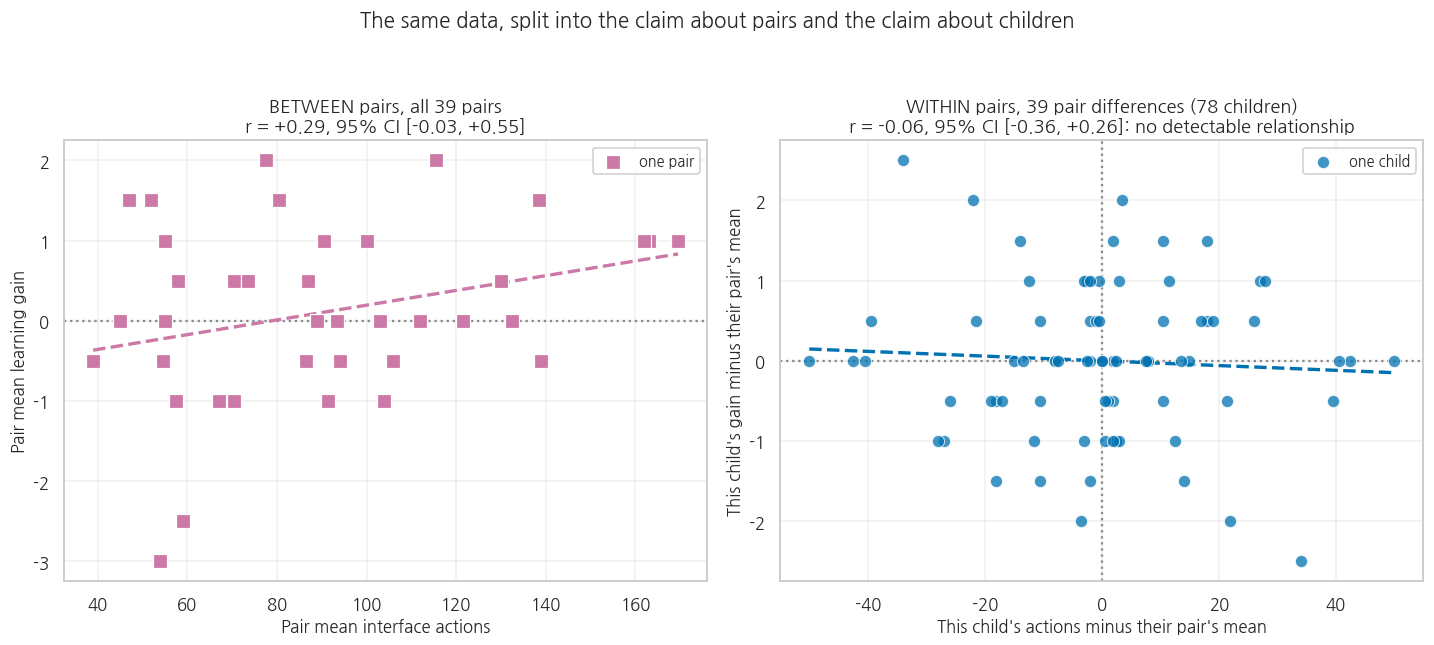

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13.2, 5.6))

ax = axes[0]
ax.scatter(tm39['a'], tm39['g'], s=90, color=PURPLE, marker='s',
           edgecolors='white', linewidths=0.8, zorder=4, label='one pair')
z = np.polyfit(tm39['a'], tm39['g'], 1)
xs = np.linspace(tm39['a'].min(), tm39['a'].max(), 50)
ax.plot(xs, np.polyval(z, xs), color=PURPLE, linewidth=2.2, linestyle='--', zorder=3)
ax.axhline(0, color=GREY, linestyle=':', linewidth=1.5, zorder=2)
ax.set_xlabel('Pair mean interface actions', fontsize=11)
ax.set_ylabel('Pair mean learning gain', fontsize=11)
ax.legend(fontsize=9.5, framealpha=0.94)
ax.set_title(f'BETWEEN pairs, all {len(tm39)} pairs\n'
             f'r = {r39:+.2f}, 95% CI [{lo39:+.2f}, {hi39:+.2f}]', fontsize=12)

d = children.copy()
wa = d['actions'] - d.groupby('team_no')['actions'].transform('mean')
wg = d['gain'] - d.groupby('team_no')['gain'].transform('mean')
r_w = np.corrcoef(wa, wg)[0, 1]
ax = axes[1]
ax.scatter(wa, wg, s=64, color=BLUE, marker='o', alpha=0.75,
           edgecolors='white', linewidths=0.7, zorder=4, label='one child')
zz = np.polyfit(wa, wg, 1)
xs = np.linspace(wa.min(), wa.max(), 50)
ax.plot(xs, np.polyval(zz, xs), color=BLUE, linewidth=2.2, linestyle='--', zorder=3)
ax.axhline(0, color=GREY, linestyle=':', linewidth=1.5, zorder=2)
ax.axvline(0, color=GREY, linestyle=':', linewidth=1.5, zorder=2)
ax.set_xlabel('This child\'s actions minus their pair\'s mean', fontsize=11)
ax.set_ylabel('This child\'s gain minus their pair\'s mean', fontsize=11)
ax.legend(fontsize=9.5, framealpha=0.94)
rw_all, lw_all, hw_all = within_pair_r(children, 'actions', 'gain')
ax.set_title(f'WITHIN pairs, {children["team_no"].nunique()} pair differences '
             f'({len(children)} children)\n'
             f'r = {rw_all:+.2f}, 95% CI [{lw_all:+.2f}, {hw_all:+.2f}]: no detectable relationship',
             fontsize=12)

fig.suptitle('The same data, split into the claim about pairs and the claim about children',
             fontsize=13.5, y=1.045)
plt.show()

**Let's discuss.**

Across all thirty-nine pairs, pair mean recorded actions and pair mean gain correlate at **r = +0.29, 95% CI [-0.03, +0.55]**. The interval contains zero, and it rests on the largest sample this corpus offers.

Within a pair, the child with more recorded actions did **not** detectably gain more than their partner: **r = -0.06, 95% CI [-0.36, +0.26]** across all seventy-eight children, and **r = -0.02, 95% CI [-0.60, +0.88]** across the twenty with both channels. Those intervals are worth reading before the point estimates. Both are centered close to nothing and wide enough to contain a moderate relationship in either direction, so what these data support is that this corpus **cannot see** a within-pair relationship, not that there is none.



| | |
|---|---|
| **What the data directly show** | Between pairs, r = +0.29 on 39 pairs, interval containing zero; within pairs, r = -0.06 with a wide interval containing zero; the ICC of interface actions is +0.53 and of pre-test score +0.00 |
| **A plausible interpretation** | Pairs with more recorded actions may have gained more together, and a child's action count is partly a property of the pair rather than of the child |
| **What these data cannot establish** | Whether the child of a pair with more recorded actions gained more than their partner, in either direction |

Three sentences follow.

1. Speech carries no detectable signal about who gained on the test, and its interval is wide.
2. Interface actions correlate with gain at the level of **the pair** at +0.29, and that interval contains zero.
3. Nothing in this corpus supports a claim about **which child of a pair** gained more, in either direction.

Sentence 3 is not "we showed there is nothing there". It is "we looked, with 39 pairs, and 39 pairs cannot answer this". 

*Connecting to the readings.* Mohammadi and colleagues (2025) review how AI methods are being used across multimodal learning analytics, and small sample sizes and ethical accountability are among the recurring concerns their review surfaces. A system that attaches a participation number to an individual child needs the within-pair claim, which is the one this corpus cannot supply.

Two questions. What does this mean for an instructor who wants an individual participation grade out of sensor data? And the harder version: this is not a defect of this particular study, since every collaborative setting has this structure, so what would a study have to do differently, and at what sample size, to license an individual claim?

### Your turn 3: run the decomposition on a channel you choose

You might set `PREDICTOR` below to any column in `children` and re-run. The cell prints all three correlations and the interval on the between-pair one.

`'adds'` (edges added), `'presses'` (button presses), `'removes'` (edges removed), and `'score_pre'` are all worth a run. `'adds'` and `'score_pre'` are each worth a run for a different reason; the appendix discusses both.

In [21]:
# TODO: change this and re-run. Options: 'actions', 'adds', 'removes', 'presses', 'score_pre'.
PREDICTOR = 'actions'

d = children.copy()
tm = d.groupby('team_no').agg(x=(PREDICTOR, 'mean'), g=('gain', 'mean'))
r_child = np.corrcoef(d[PREDICTOR], d['gain'])[0, 1]
r_between = np.corrcoef(tm['x'], tm['g'])[0, 1]
lo_b, hi_b = fisher_ci(r_between, len(tm))
wx = d[PREDICTOR] - d.groupby('team_no')[PREDICTOR].transform('mean')
wg = d['gain'] - d.groupby('team_no')['gain'].transform('mean')
r_within = np.corrcoef(wx, wg)[0, 1]

print(f'Predictor: {PREDICTOR}   Outcome: gain   n = {len(d)} children in {len(tm)} pairs')
print(f'  ICC of {PREDICTOR:<12} = {icc1(d, PREDICTOR, "team_no"):+.3f}'
      '   (how much of it is a property of the pair)')
print()
print(f'  child level, nesting ignored   r = {r_child:+.3f}')
print(f'  BETWEEN pairs                  r = {r_between:+.3f}, 95% CI [{lo_b:+.3f}, {hi_b:+.3f}]')
print(f'  WITHIN pairs                   r = {r_within:+.3f}')
print()
icc_val = icc1(d, PREDICTOR, 'team_no')
if icc_val > 0.85:
    print(f'  CAUTION. An ICC of {icc_val:.2f} means the two children of a pair are almost')
    print(f'  identical on {PREDICTOR}: the mean gap inside a pair is '
          f'{(d[PREDICTOR] - d.groupby("team_no")[PREDICTOR].transform("mean")).abs().mean() * 2:.1f} '
          f'against a mean of {d[PREDICTOR].mean():.1f}.')
    print('  A within-pair correlation computed on deviations that small is unstable,')
    print('  and more importantly this channel cannot tell the two children apart at')
    print('  all. Whatever the reason, it is not a measure of an individual.')
elif abs(r_between) > 2 * abs(r_within) + 0.05:
    print('  The child-level number mostly reflects the between-pair number.')
    print('  It reads as a claim about pairs rather than about children.')
elif abs(r_within) > abs(r_between):
    print('  Most of the relationship is within pairs, which is the only')
    print('  case that speaks about individuals.')
else:
    print('  The two components are of similar size. Report both and say so.')

Predictor: actions   Outcome: gain   n = 78 children in 39 pairs
  ICC of actions      = +0.529   (how much of it is a property of the pair)

  child level, nesting ignored   r = +0.170
  BETWEEN pairs                  r = +0.289, 95% CI [-0.029, +0.554]
  WITHIN pairs                   r = -0.059

  The child-level number mostly reflects the between-pair number.
  It reads as a claim about pairs rather than about children.


---

## 6. How fragile is a number built on ten pairs?

Two checks.

**Check one: leave one pair out.** Drop each of the ten pairs in turn, recompute, and look at the spread. If dropping one pair moves the number across a boundary you care about, the number is partly a property of that pair.

**Check two: the same number in two files.** `per_participant.csv` gives twenty children with both channels. `participant_with_team_channels.csv` gives eighteen, because one of the ten transcribed teams is among the teams absent from the PE-HRI release, which holds 68 of the 78 children. The two children absent from the second file were not excluded by us, and the release does not say why their team is absent.

**Run the cell below.**

In [22]:
teams_both = sorted(both['team_no'].unique())

print('LEAVE ONE PAIR OUT\n')
loo = {}
for label, (xc, yc) in {'speech share vs action share': ('sh_speech_secs', 'sh_actions'),
                        'interface actions vs gain': ('actions', 'gain')}.items():
    full = np.corrcoef(both[xc], both[yc])[0, 1]
    vals = []
    for t in teams_both:
        s = both[both['team_no'] != t]
        vals.append((t, float(np.corrcoef(s[xc], s[yc])[0, 1])))
    loo[label] = (full, vals)
    rs = [v for _, v in vals]
    print(f'{label}')
    print(f'  all 10 pairs      r = {full:+.3f}')
    print(f'  leave-one-out     r ranges {min(rs):+.3f} to {max(rs):+.3f}')
    worst = max(vals, key=lambda kv: abs(kv[1] - full))
    print(f'  most influential pair: team {worst[0]} (drop it and r becomes {worst[1]:+.3f})')
    print()

print('THE SAME NUMBER IN TWO FILES\n')
both_joined = joined.dropna(subset=['speech_secs']).copy()
lost = sorted(set(both['team_no']) - set(both_joined['team_no']))
print(f'  per_participant.csv            : {len(both)} children with both channels, '
      f'{both["team_no"].nunique()} pairs')
print(f'  participant_with_team_channels : {len(both_joined)} children with both channels, '
      f'{both_joined["team_no"].nunique()} pairs')
print(f'  pairs present in the first and absent from the second: {lost}')
print()
r_a = np.corrcoef(both['actions'], both['gain'])[0, 1]
r_b = np.corrcoef(both_joined['actions'], both_joined['gain'])[0, 1]
print(f'  interface actions ~ gain, 20 children : r = {r_a:+.3f}')
print(f'  interface actions ~ gain, 18 children : r = {r_b:+.3f}')
print(f'  one absent pair moves the headline correlation by {abs(r_a - r_b):.3f}.')

LEAVE ONE PAIR OUT

speech share vs action share
  all 10 pairs      r = +0.208
  leave-one-out     r ranges -0.019 to +0.353
  most influential pair: team 10 (drop it and r becomes -0.019)

interface actions vs gain
  all 10 pairs      r = +0.404
  leave-one-out     r ranges +0.298 to +0.569
  most influential pair: team 17 (drop it and r becomes +0.569)

THE SAME NUMBER IN TWO FILES

  per_participant.csv            : 20 children with both channels, 10 pairs
  participant_with_team_channels : 18 children with both channels, 9 pairs
  pairs present in the first and absent from the second: [11]

  interface actions ~ gain, 20 children : r = +0.404
  interface actions ~ gain, 18 children : r = +0.332
  one absent pair moves the headline correlation by 0.072.


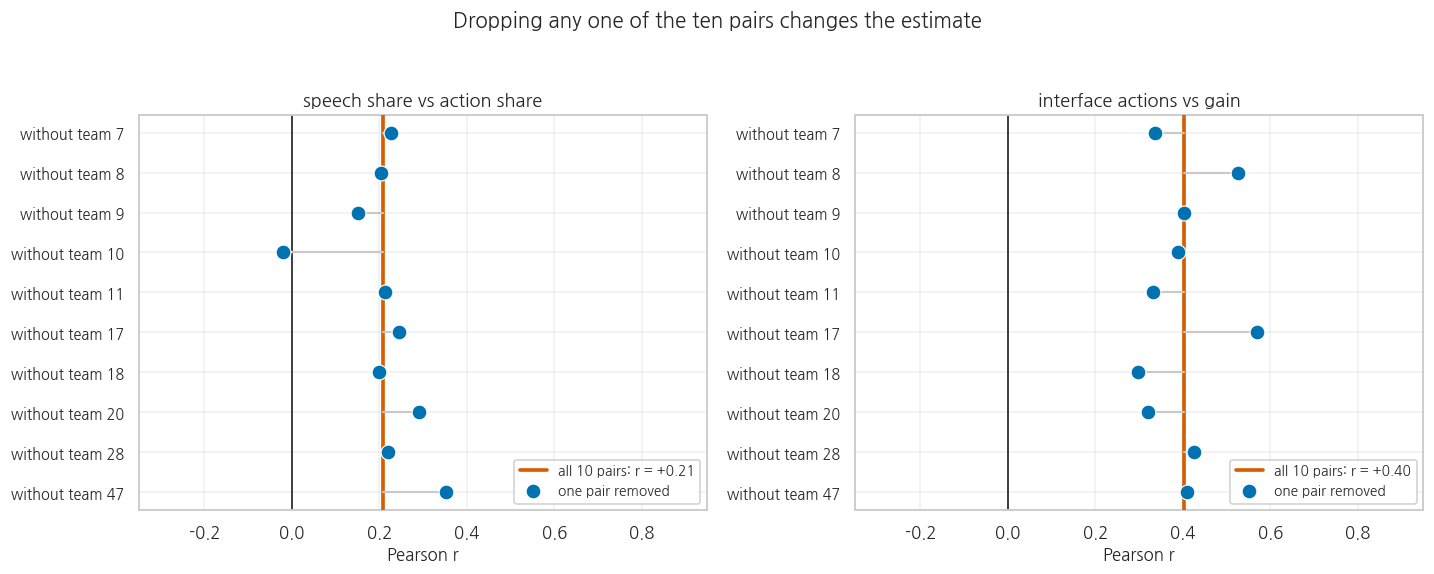

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(13.2, 5.0), sharey=False)

for ax, (label, (full, vals)) in zip(axes, loo.items()):
    ts = [t for t, _ in vals]
    rs = [r for _, r in vals]
    y = np.arange(len(ts))[::-1]
    ax.axvline(0, color='#333333', linewidth=1.2, zorder=2)
    ax.axvline(full, color=ORANGE, linewidth=2.4, zorder=3,
               label=f'all 10 pairs: r = {full:+.2f}')
    ax.scatter(rs, y, s=95, color=BLUE, marker='o', edgecolors='white',
               linewidths=0.8, zorder=5, label='one pair removed')
    for yy, rr in zip(y, rs):
        ax.plot([full, rr], [yy, yy], color='#c9c9c9', linewidth=1.4, zorder=4)
    ax.set_yticks(y); ax.set_yticklabels([f'without team {t}' for t in ts], fontsize=9.5)
    ax.set_xlabel('Pearson r', fontsize=11)
    ax.set_xlim(-0.35, 0.95)
    ax.set_title(label, fontsize=12)
    ax.legend(fontsize=9, loc='lower right', framealpha=0.94)

fig.suptitle('Dropping any one of the ten pairs changes the estimate',
             fontsize=13.5, y=1.04)
plt.show()

**Let's discuss.** Drop team 10 and the speech-versus-actions correlation falls from **+0.21 to -0.02**. The actions-versus-gain correlation ranges from **+0.30 to +0.57** depending on which single pair is removed, and the most influential one is team 17.

Then look at what dropping team 11 does: **+0.40 becomes +0.33**, which is the number you would have reported had you loaded the joined file without checking which pairs it contains.

One sentence for the memo about what a single-pair swing means for reporting a two-decimal correlation from a study this size. Then a second about the file question: no error or warning is raised, and the file with the more complete-sounding name gives a different number. Please name one habit that would have caught it.

---

## 7. The column that is not there

In Week 3 and Week 5, this is where we disaggregated. We take the measure, split it by who the students are, and ask whether it works the same way for everybody. Week 3 did that with deprivation deciles. Week 5 did it with the writer groups recorded in PERSUADE.

So let us try it here. The release does not say where the sessions ran or in what language. If the activity language was not every child's first language, and the microphone were an uneven instrument, language background is a place where that might show.

**Run the cell below.**

In [24]:
# The analysis we would run in any other week. Run it and see what happens.
try:
    by_language = children.groupby('first_language')['sh_speech_secs'].mean()
    print(by_language)
except KeyError as e:
    print('KeyError:', e)
    print()
    print("There is no such column. So let us find out what else is not there.")

KeyError: 'first_language'

There is no such column. So let us find out what else is not there.


In [25]:
# A systematic audit. Scan every column of all four files for anything that
# records an attribute of a person rather than a behavior or an outcome.
PERSON_PATTERNS = [
    r'\bage\b', r'\bgender\b', r'\bsex\b', r'langua', r'\bl1\b', r'native', r'ethnic',
    r'\brace\b', r'\bses\b', r'income', r'disab', r'\bgrade\b', r'birth', r'nation',
    r'country', r'school', r'migrant', r'\bname\b', r'famil', r'parent', r'\bclass\b',
]

FILES = [('per_participant.csv', children),
         ('participant_with_team_channels.csv', joined),
         ('pehri_team_outcomes.csv', team_out),
         ('pehri_temporal.csv.gz', temporal)]

all_cols = [(f, c) for f, df in FILES for c in df.columns]
hits = [(f, c) for f, c in all_cols
        if any(re.search(p, c.lower()) for p in PERSON_PATTERNS)]

print(f'Columns scanned across all four files : {len(all_cols)}')
print(f'Columns recording an attribute of a child: {len(hits)}')
print(f'  {hits if hits else "(none)"}')
print()


def what_it_records(col):
    n = col.lower().replace('_inc', '')
    if n.startswith('sh_'):
        return 'Share of the pair (added when this file was packaged)'
    if n in ('unnamed: 0', 'team_no', 'who', 'team', 'time_in_secs', 'window',
             'normalized_time', 'cluster_labels'):
        return 'Bookkeeping: which row, which team, which moment'
    if n in ('score_pre', 'score_post', 'gain', 'last_error', 'pe_score') or n.startswith('t_lg'):
        return 'Learning outcome or task performance'
    if any(k in n for k in ['speech', 'turns', 'words', 'voice_activity', 'silence',
                            'pauses', 'overlap']):
        return 'Speech channel'
    if 'gaze' in n or n in ('at_partner', 'screen_left', 'screen_right',
                            'screen_right_left_ratio', 'at_robot', 'other'):
        return 'Gaze channel'
    if any(k in n for k in ['valence', 'arousal', 'smile', 'positive', 'negative']):
        return 'Affect channel'
    if any(k in n for k in ['action', 'add', 'remove', 'press', 'hist', 'help',
                            'redundant', 'ratio', 't1_']):
        return 'Interface and problem-solving actions'
    return 'UNCLASSIFIED'


tally = pd.Series([what_it_records(c) for _, c in all_cols]).value_counts()
tally['Attributes of the child (who they are)'] = 0
print('What all', len(all_cols), 'columns record:')
print(tally.to_string())
print()
print('Nothing is left unclassified:', 'UNCLASSIFIED' not in tally.index)

Columns scanned across all four files : 125
Columns recording an attribute of a child: 0
  (none)

What all 125 columns record:
Interface and problem-solving actions                    41
Speech channel                                           24
Gaze channel                                             16
Bookkeeping: which row, which team, which moment         13
Affect channel                                           13
Learning outcome or task performance                     11
Share of the pair (added when this file was packaged)     7
Attributes of the child (who they are)                    0

Nothing is left unclassified: True


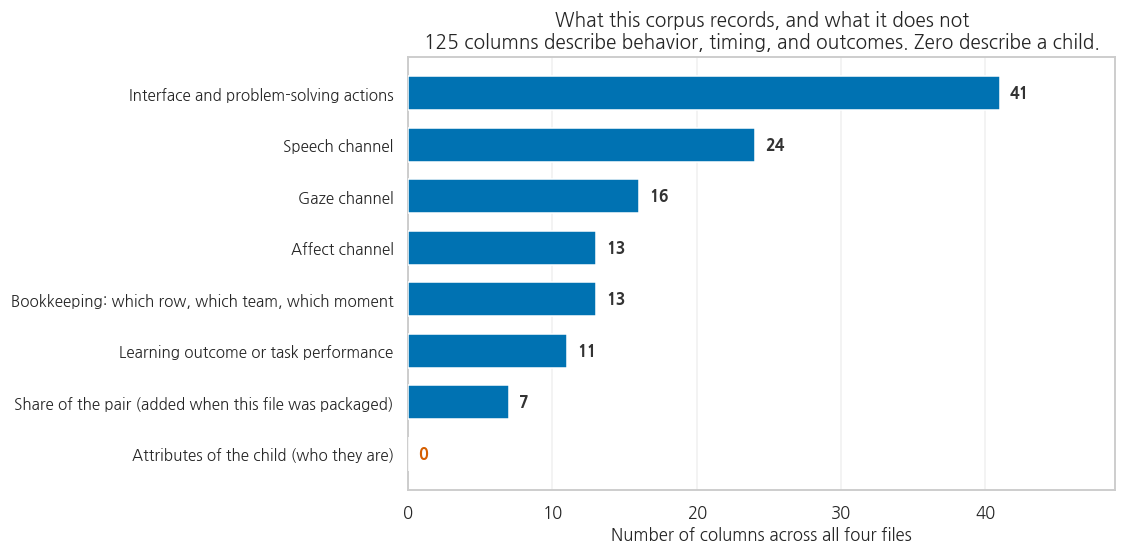

In [26]:
fig, ax = plt.subplots(figsize=(10.4, 5.2))
t = tally.sort_values()
colors = [ORANGE if v == 0 else BLUE for v in t.values]
bars = ax.barh(range(len(t)), t.values, color=colors, height=0.66, zorder=3)
for i, v in enumerate(t.values):
    ax.text(v + 0.7, i, str(v), va='center', fontsize=10.5, fontweight='bold',
            color=ORANGE if v == 0 else '#333333')
ax.set_yticks(range(len(t)))
ax.set_yticklabels(t.index, fontsize=10)
ax.set_xlabel('Number of columns across all four files', fontsize=11)
ax.set_xlim(0, max(t.values) + 8)
ax.grid(axis='y', visible=False)
ax.set_title('What this corpus records, and what it does not\n'
             f'{len(all_cols)} columns describe behavior, timing, and outcomes. Zero describe a child.',
             fontsize=12.5)
plt.show()

**Let's discuss.**

Across the four files there are forty-one columns of recorded interface actions, twenty-four of recorded speech, sixteen of gaze estimates, and thirteen of affect estimates. There are **none for who they were.**

The published corpus records the age range, 9 to 12, in its documentation (Norman et al., 2021; Nasir et al., 2021), and nothing else: no gender, no first language, no school, and no indication of anything about the children's circumstances.

**So the equity analysis cannot be run on these files.** The files do not contain what the analysis would require.

The middle row is where care is needed most.

| | |
|---|---|
| **What the data directly show** | 125 columns across four files, of which 0 record any attribute of a child; the documentation gives an age range and no other person-level variable |
| **A plausible interpretation** | The activity language is not stated in the release; if it was not every child's first language, variation in language background was plausibly present, and transcription and voice activity detection can perform unevenly across accents and speaking styles |
| **What these data cannot establish** | Whether any such variation existed among these particular children, whether it affected their speech records, or how any measure here would differ across groups |

The middle row is a statement about the setting and about instruments in general rather than a claim about any child in this corpus. Nothing in the release lets us check it, and the channel where a check would matter most, speech, is the one present for a quarter of the sample.

**The absence is itself a finding, and it belongs in the memo.** A corpus that records forty-one columns about clicking and none about the children makes a certain kind of question unanswerable, for everyone who uses the file.

Two sentences to draft. The first names one thing the original research team could have released, consistent with protecting children aged 9 to 12, that would have allowed the question to be asked. The second is harder: what is a real reason a research team might decide not to release it, and who bears the cost of that decision?

*Connecting to the readings.* Worsley, Martinez-Maldonado, and D'Angelo (2021) propose twelve commitments for multimodal learning analytics, arguing that the field is accountable to the people it senses rather than only to what its sensors can capture. Lee, Sung, Celedón-Pattichis, and Pattichis (2026) examine multimodal participation dynamics by gender and linguistic diversity, and their argument for an inclusive reading of collaborative participation depends on knowing something about who is in the group. This section is where those two readings apply to a file with no person-level variables.

### 7.1 Gated corpora and this one

Much multimodal learning data sits behind data use agreements.

The corpora that would fit this lab best are gated. Several of the best-known multimodal collaborative learning corpora appear, at the time of writing, to be reachable only by request, under an agreement, or through an institutional relationship, rather than by clicking a link. Multimodal data is unusually identifying, video and audio of children most of all, and gating is a serious and defensible response to that.

**That claim is worth checking rather than taking on trust.** One recent paper on collaborative multimodal analytics, and what its data availability statement says, would settle it for that corpus. If one turns out to be more open than this paragraph implies, please say so and we will revise the paragraph.

But **this** corpus is not gated. You downloaded it, in a browser, with no login, under **CC BY 4.0**, and your analysis of it can be redistributed under the license.

The CHILI lab at EPFL released anonymized transcripts, event logs, test responses, and derived features rather than raw audio and video, wrote the documentation, deposited it on Zenodo, and chose a permissive license.

**Gating is a choice**; a "data available on request" line records a decision about what to release.

What was traded: this release is open partly because what was released is derived features rather than raw video and audio, and partly because it carries no direct identifier of any child. Openness and richness were traded against each other, and somebody chose.

### Your turn 4 (optional): audit a corpus yourself

This one is optional, and it is not a code cell, because the skill is not a code skill. It belongs with the **Going further** section near the end of the notebook.

You might pick **one** open multimodal or collaboration dataset other than this one. Some starting points: the **DAiSEE** engagement video dataset, the **MELD** multimodal conversation corpus, the **AMI Meeting Corpus**, or any dataset attached to a paper at the last two Learning Analytics and Knowledge conferences. Zenodo, the Open Science Framework, and the paper's data availability statement are the usual places to look. Whether each can be downloaded today without asking anyone is the second row of the table.

Then this table, filled in and brought to class:

| Question | Your answer |
|---|---|
| Name, authors, year, and DOI | |
| License, and whether you can download it today without asking anyone | |
| How many people, and how many have every modality | |
| Which columns record what a person **did** | |
| Which columns record who a person **is** | |
| If the second list is empty, does the paper still make claims about groups of people | |
| What would you need to run an equity analysis, and who could give it to you | |

The last row is the one to prepare. The interesting cases are papers that discuss fairness in the discussion section using a corpus that could not have supported the analysis.

---

## 8. The finest-grained file has no child in it



`pehri_temporal.csv.gz` describes 32 of the teams in **10-second windows**: 4,676 rows, about thirteen hours of interaction. It has speech activity, silence, overlap, gaze at four targets plus an other category, inferred affect, and a running count of every action on the map.

And it has no `who` column. Every value in it describes the pair.

The `_inc` columns accumulate: for counts they are running totals, for rates they are running averages. **Run the cell below.** It checks that claim for one count column and one rate column, audits the gaze columns, then cross-checks the derived team file against the raw child file.

In [27]:
FOCUS_TEAM = 47
tw = temporal[temporal['team'] == FOCUS_TEAM].sort_values('window').reset_index(drop=True)

# Verify what the _inc suffix means, rather than believing a README.
run_total = tw['T_action'].cumsum()
run_mean = tw['T_speech_activity'].expanding().mean()
print(f'Team {FOCUS_TEAM}: {len(tw)} windows of 10 seconds '
      f'= {tw["time_in_secs"].max() / 60:.1f} minutes\n')
print(f'  T_action_inc is a running TOTAL of T_action          : '
      f'{np.allclose(run_total, tw["T_action_inc"])}')
print(f'  T_speech_activity_inc is a running MEAN of its column: '
      f'{np.allclose(run_mean, tw["T_speech_activity_inc"])}')
print()

# The fourth file, checked against the first. A derived file should reproduce
# the raw one exactly, and when it does you have earned the right to use it.
tm_gain = children.groupby('team_no')['gain'].mean().rename('pair_mean_gain')
chk = team_out.set_index(team_out['team'].astype(int)).join(tm_gain, how='inner')
gap = (chk['T_LG_absolute'] - chk['pair_mean_gain'] / 10).abs().max()
print(f'CHECKING the derived team file against the raw child file '
      f'({len(chk)} teams)\n')
print(f'  T_LG_absolute equals the pair mean gain divided by 10, to within {gap:.1e}.')
print('  So it is the same number in different units, not extra information.')
print('  Reporting both would be reporting one thing twice.')
print()
r_le = float(np.corrcoef(chk['pair_mean_gain'], chk['last_error'])[0, 1])
lo_le, hi_le = fisher_ci(r_le, len(chk))
print(f'  last_error is what the PE-HRI documentation calls the error of the last submitted solution (Nasir et al., 2021):')
print(f'    mean {chk["last_error"].mean():.3f}, and {int((chk["last_error"] == 0).sum())} '
      f'of {len(chk)} pairs have last_error = 0, where the documentation says the activity stopped because the team found an optimal solution.')
print(f'    pair mean gain ~ last_error   r = {r_le:+.3f}, 95% CI [{lo_le:+.3f}, {hi_le:+.3f}]')
print('    The interval rules out a strong positive association between finishing with a')
print('    correct map and gaining on the test, and little else.')
print()
gaze_cols = [c for c in temporal.columns if 'gaze' in c.lower() and not c.endswith('_inc')]
if len(gaze_cols) == 5:
    gsum = temporal[gaze_cols].sum(axis=1)
    print(f'GAZE AUDIT: the five gaze columns sum to exactly 100 in {(gsum.round(6) == 100).mean():.1%} of rows,')
    print(f'  are within five points of 100 in {((gsum - 100).abs() <= 5).mean():.1%}, and range from {gsum.min():.1f} to {gsum.max():.1f}.')
    print('  Decision: gaze is plotted below only as an illustration; no number in this notebook is computed from it.')
else:
    print(f'GAZE AUDIT: expected five gaze columns, found {gaze_cols}. Gaze is plotted below only as an illustration.')

# And a real inconsistency, found by cross-checking rather than assumed away.
tot_temporal = temporal.groupby(temporal['team'].astype(int))['T_action_inc'].max()
tot_children = children.groupby('team_no')['actions'].sum()
comp = pd.concat([tot_temporal.rename('temporal_file'),
                  tot_children.rename('sum_of_two_children')], axis=1).dropna()
comp['difference'] = comp['temporal_file'] - comp['sum_of_two_children']
print(f'Total actions per team, from two different files ({len(comp)} teams comparable):')
print(f'  exact agreement      : {(comp["difference"] == 0).sum()} of {len(comp)} teams')
print(f'  difference ranges    : {comp["difference"].min():+.0f} to {comp["difference"].max():+.0f} actions')
print(f'  mean absolute gap    : {comp["difference"].abs().mean():.1f} actions '
      f'({(comp["difference"].abs() / comp["sum_of_two_children"]).mean():.1%} of the team total)')
print()
print(f'  Team {FOCUS_TEAM}: temporal file says '
      f'{comp.loc[FOCUS_TEAM, "temporal_file"]:.0f}, the two children sum to '
      f'{comp.loc[FOCUS_TEAM, "sum_of_two_children"]:.0f}.')
print()
print('  The released documentation does not resolve this, and we are not going to')
print('  invent an explanation. The decision we make is: use per-child counts for')
print('  per-child questions and team counts for team questions, and never divide')
print('  one by the other. The cost of that decision is that we cannot convert a')
print('  temporal action count into a per-child share.')

Team 47: 117 windows of 10 seconds = 19.5 minutes

  T_action_inc is a running TOTAL of T_action          : True
  T_speech_activity_inc is a running MEAN of its column: True

CHECKING the derived team file against the raw child file (34 teams)

  T_LG_absolute equals the pair mean gain divided by 10, to within 1.1e-16.
  So it is the same number in different units, not extra information.
  Reporting both would be reporting one thing twice.

  last_error is what the PE-HRI documentation calls the error of the last submitted solution (Nasir et al., 2021):
    mean 0.202, and 8 of 34 pairs have last_error = 0, where the documentation says the activity stopped because the team found an optimal solution.
    pair mean gain ~ last_error   r = -0.100, 95% CI [-0.424, +0.246]
    The interval rules out a strong positive association between finishing with a
    correct map and gaining on the test, and little else.

GAZE AUDIT: the five gaze columns sum to exactly 100 in 8.0% of rows,
  are wit

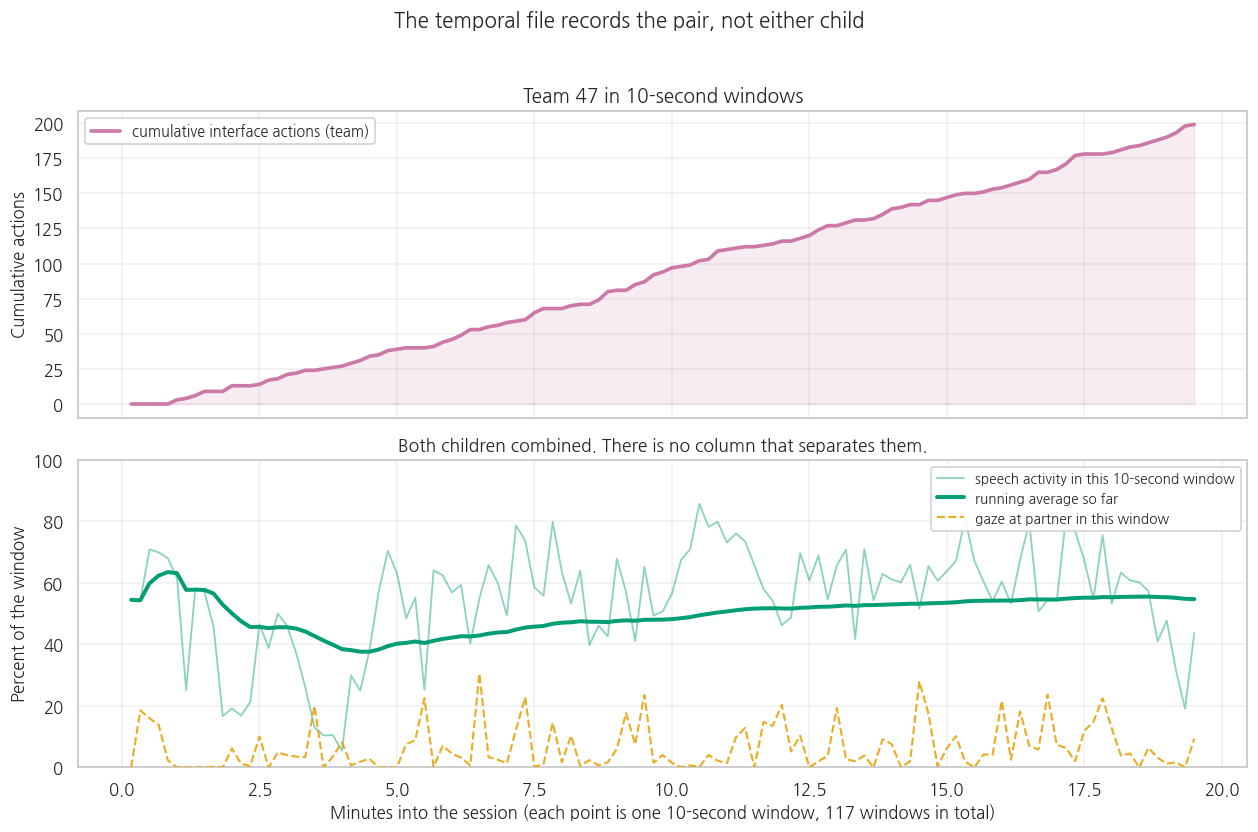

In [28]:
fig, axes = plt.subplots(2, 1, figsize=(11.6, 7.4), sharex=True,
                         gridspec_kw={'height_ratios': [1, 1]})
mins = tw['time_in_secs'] / 60

ax = axes[0]
ax.plot(mins, tw['T_action_inc'], color=PURPLE, linewidth=2.4, zorder=4,
        label='cumulative interface actions (team)')
ax.fill_between(mins, 0, tw['T_action_inc'], color=PURPLE, alpha=0.14, zorder=2)
ax.set_ylabel('Cumulative actions', fontsize=11)
ax.legend(loc='upper left', fontsize=9.5, framealpha=0.94)
ax.set_title(f'Team {FOCUS_TEAM} in 10-second windows',
             fontsize=12.5)

ax = axes[1]
ax.plot(mins, tw['T_speech_activity'], color=GREEN, linewidth=1.2, alpha=0.45, zorder=3,
        label='speech activity in this 10-second window')
ax.plot(mins, tw['T_speech_activity_inc'], color=GREEN, linewidth=2.6, zorder=5,
        label='running average so far')
ax.plot(mins, tw['gaze_at_partner'], color=GOLD, linewidth=1.4, linestyle='--',
        alpha=0.85, zorder=4, label='gaze at partner in this window')
ax.set_ylabel('Percent of the window', fontsize=11)
ax.set_xlabel(f'Minutes into the session (each point is one 10-second window, '
              f'{len(tw)} windows in total)', fontsize=11)
ax.set_ylim(0, 100)
ax.legend(loc='upper right', fontsize=9, framealpha=0.94, ncol=1)
ax.set_title('Both children combined. There is no column that separates them.', fontsize=11.5)

fig.suptitle('The temporal file records the pair, not either child',
             fontsize=13.5, y=1.02)
plt.show()

**Let's discuss.** In Section 4 you saw that team 47's two children split the talking 76 to 24. This figure covers the same twenty minutes at ten-second resolution and shows a single green line.

What would that green line look like if it were split by child, given what Section 4 showed about that pair? And a second question: this file was built for a research question about **team** engagement (Nasir et al., 2021). What would have had to change about the feature extraction, rather than about the analysis, for it to answer ours, and would that change have been cheap?

---

## 9. Reflection: tie it to the readings

Please answer these in the markdown cell below (double-click it to type). Two to four sentences each. These are the notes you will draw on for the memo.

**1. Ochoa (2022).** Ochoa lays out the MMLA pipeline from physical signal to sensor to feature to interpretation, and argues that every stage is a modeling choice that discards information. It may be useful to trace `speech_secs` backwards through that pipeline for these children. What physical event produced it, what had to be decided to turn that event into a number of seconds, and what did the number set aside? Then the same for `actions`, and which of the two you think lost more.

**2. Worsley, Martinez-Maldonado, and D'Angelo (2021).** Their twelve commitments argue that MMLA is accountable to the people it senses, not only to the sensors. Section 7 found a corpus with 125 columns and none of them about the children. Which of the twelve commitments does that absence strain hardest, and would releasing the missing columns have strained a different one? The question asks for a real trade-off rather than a side.

**3. Lee, Sung, Celedón-Pattichis, and Pattichis (2026).** This study examines multimodal participation dynamics by gender and linguistic diversity and argues for an inclusive reading of collaborative participation. You could not replicate it this week. Which part of their argument could your data still speak to, which part could it not, and what would it take to run their analysis on a corpus like this one?

**4. Mohammadi and colleagues (2025).** Their review maps how AI is being used across MMLA. Given Section 5.2, where no correlation's interval excluded zero and the one closest to doing so was about pairs rather than children, what would you require of an automated multimodal participation system before letting it produce a number attached to an individual student's name?

**5. Norman et al. (2021) and Nasir et al. (2021), the people who released this data.** Name two decisions they made that you would want the next research team to copy, and one you would want changed.

**6. Your own context.** In the setting you care about, your dissertation site, your classroom, your program, which channel is currently standing in for "participation"? Now apply Section 5.2 to it: is the evidence you have for that channel a between-group claim or a within-group one, and which one is your setting using it to make?

### Your reflection

*Double-click this cell to edit it. Delete this line and write here.*

**1. Ochoa (2022):**

**2. Worsley, Martinez-Maldonado, and D'Angelo (2021):**

**3. Lee, Sung, Celedón-Pattichis, and Pattichis (2026):**

**4. Mohammadi et al. (2025):**

**5. Norman et al. (2021) and Nasir et al. (2021):**

**6. Your own context:**

---

## 10. Deliverable: the inclusive participation memo

This memo is the **primary component used for grading** in Mini Project 3. Please write about **500 to 700 words** in the cell below, addressed to a colleague who runs a collaborative problem-solving unit and has asked a plain question:

> **"We are already logging what students click and we could add a microphone. Can I use this to give each student a participation grade?"**

The memo asks for all of the following.

1. **What you found.** Use at least two figures or tables from this notebook by name and give the actual numbers, with intervals rather than point estimates alone. At minimum: the agreement between the two channels, the proportion of pairs that swap, and the between-pair versus within-pair decomposition.

2. **The measurement problem, in plain language.** Explain to a colleague with no statistics background what 'no detectable relationship' means for speech seconds and gain, why it is not the same as 'no relationship', and why the larger point estimate for interface actions is not a result either. Team 47 is available as an example.

3. **A position on the nesting.** Explain why "pairs that did more work learned more" does not license "the child who did more work learned more", and say what your colleague would have to measure to support the second claim. 

4. **A recommendation you can live with.** Either a defensible use of these signals, saying exactly what goes in and what it is allowed to be used for, or a defensible refusal, saying what you would use instead and why sensors are the wrong tool for this particular decision. **A clear refusal, well argued, earns full credit.**

5. **The limits, including the one that is an absence.** The limits are twenty children in ten pairs, a 10-item test whose mean gain interval contains zero, ten teams transcribed out of thirty-nine by an unknown selection rule, and no column anywhere in 125 columns recording anything about who these children were. Which limit worries you most, and why?

Please anchor the argument in the readings by author name, and without fabricating page numbers or quotations. Please also avoid describing any child in this corpus in terms of what they lacked: every number here is a record of what an instrument caught.

### Inclusive Participation Memo

*Double-click to edit. Replace this text with your memo (about 500 to 700 words).*

**To:** A colleague running a collaborative problem-solving unit
**From:** [your name]
**Date:** September 30, 2026
**Re:** Whether logged and recorded participation can support an individual grade

**What the two channels said about the same children**

**What each channel's interval permits about who gained**

**Pairs are not children: what the nesting does to the claim**

**Recommendation**

**Limits, including the one that is missing from the file**

---

## 11. Submission checklist

Mini Project 3 is due on Canvas by **11:59 PM on Sunday, October 4, 2026**. There are **three things** to submit:

- [ ] **This notebook**, run top to bottom with all outputs visible. In Colab: `File > Download > Download .ipynb`, then upload to the Canvas assignment "Mini Project 3". Name it `LastName_MiniProject3.ipynb`.
- [ ] **The inclusive participation memo** (Section 10), either inside the notebook cell or as a separate document, 500 to 700 words. This is the primary component used for grading.
- [ ] **Your AI interaction log plus reflection**, in the Canvas "AI Reflection" submission. See the reminder below for which part goes where.

Before submitting, it is worth confirming:

- [ ] `Runtime > Restart session and run all` finishes with no errors.
- [ ] Every figure in your submitted notebook has a title and labeled axes, including any you added.
- [ ] You responded to the interpretation prompts, including the ones that took longer.
- [ ] Section 9 is complete and names the authors, including the two data citations.
- [ ] **Every number in your memo carries its interval or its sample size.** 
- [ ] You cited the data. Norman et al. (2021), Zenodo 4627104; Nasir et al. (2021), Zenodo 4633092; and, if you used the temporal file, Nasir, Bruno, and Dillenbourg (2024), Zenodo 13834073. All three CC BY 4.0. The license requires attribution.

**Also due this week:** the **Mid-Semester Check-In**, a separate short Canvas submission. It is not part of Mini Project 3 and it is not graded on quality. It is how the second half of the course gets adjusted to the people in the seminar, so please answer it honestly.

### AI documentation reminder

Course policy: **AI use is permitted in designated activities and must be documented.** If you used a chatbot or coding assistant for any part of this project, for debugging, wording, statistics, or interpretation, the policy asks for two separate pieces, submitted in two different places:

**1. The conversation record goes in a Word file.** Export every relevant exchange, across every session and every tool you used, paste it into a Word document, and attach that file to the Canvas "AI Reflection" submission. Please do not paste your transcript into the Canvas text box.

**2. The reflection goes in the Canvas text box.** Copy these four questions into the box and answer each one:

1. How did you use it?
2. Did AI help you with your work this week? If so, how?
3. Did it make your work more challenging in any way? If so, how?
4. What new lesson or lessons, if any, could you share with a friend or the class that summarize what you learned about AI through this week's work?

Two things worth reflecting on specifically this week. First, if an AI tool computed or interpreted a correlation for you, did it mention the nesting? Most will not, unless you tell them the rows are children inside pairs. It is worth saying what you had to add to the prompt to get a correct answer. Second, if you asked a tool to explain the equity implications of this dataset, it is worth checking whether it invented a demographic variable. Section 7 shows there is no such column.

You are not graded on how much or how little you used AI. You are graded on the rubric and on the quality of your final product. Undisclosed AI use is an Honor Code violation. Disclosed use is normal scholarly practice.

---

## Going further (optional)

Nothing below is needed for the memo.

**Your turn 4** above, the audit of another corpus, belongs with this section: it is preparation to bring to class rather than part of the graded project.

The README for this week lists five stretch goals for anyone who finishes early or arrives with programming experience: the gaze and affect channels in the joined file, which are team values repeated on both of a pair's rows; rebuilding Section 5 as a mixed model with `statsmodels`; using the temporal file for a genuinely temporal question; comparing the ten transcribed teams against the other twenty-nine on everything the complete files record; and drafting the missing-data statement the original authors could have published. None of them is required.

---

## Appendix: worked notes on the Your turn cells

These are worked examples, not the only right answers.

**Your turn 1 (a different pair of channels).** With the default, share of speaking turns against share of speech seconds, the correlation comes out very high, and that is what we would expect: they are two readings of the same microphone on the same person. It works as a calibration point. It shows what agreement between channels looks like in this dataset, which makes the +0.21 between speech and actions easier to read.

`'presses'` against `'adds'`: both come out of the same event log, and if the button-presser and the track-drawer were the same child in every pair, they would agree strongly. Whatever you find, the interval belongs with it: with ten pairs, most of these come back with intervals wide enough to cover a strong relationship in one direction and a moderate one in the other, and a careful write-up says so.

**Your turn 2 (ask for a bigger gap).** Six of the ten pairs put the same child at least 5 percentage points apart on the two channels, four are at least 10 points apart, three at least 15, two at least 20, and none reaches 30. The two large ones are team 47 at 0.297 and team 17 at 0.278, and they are the two pairs with the most lopsided talk in the corpus.

The disagreement is present at gaps of 0.10 and 0.20 and absent at 0.30. The narrowest Wilson interval in that table is 28 percentage points wide and most are around 50, which means no single row is quotable on its own. A defensible sentence for the memo names the number **and** the gap size **and** the interval, or shows the scatter and skips the count. A sentence like "half the pairs disagreed" with no threshold attached is one a reader cannot check.

**Your turn 3 (decompose a channel of your choice).** The runs below are each worth doing, and each one teaches something different.

`'actions'` is the section's own example. ICC **+0.53**: about half of a child's action count is a property of their pair rather than of them. Between pairs **+0.29**, within pairs **-0.06**.

`'adds'`: its ICC is **+0.95**. The two children of a pair add almost exactly the same number of edges as each other: the mean gap inside a pair is **4.3 edges against a mean of 39.4**, and across all 78 children the add share never leaves the range 0.38 to 0.62, where the action share runs from 0.27 to 0.73; the cell below prints all four. Whatever produced that, and the released files do not tell us, the consequence is fixed: **`adds` cannot distinguish the two children of a pair.** A dashboard reporting "edges contributed" on this activity would show a near-perfect fifty-fifty split for almost every pair and would look equitable while not distinguishing the two children. A channel that is equal because the instrument cannot separate people is not evidence of equal participation.

`'score_pre'` is the control. Its ICC is about **0.00**, meaning the pre-test score is almost purely a property of the individual child, so the pre-test score is a property of the child rather than of the pair. That contrast against `actions` is the clearest way to see why the two variables cannot support the same kind of claim.

One caution. `score_pre` correlates with `gain` at about **-0.44**, and it does so both between and within pairs. That is not a finding about who learns. `gain` is `score_post` minus `score_pre`, so the two share a term, and on a 10-item test a child who scored 9 can gain at most 1 while a child who scored 3 has room for 7. That is regression to the mean plus a ceiling effect, and it is a useful reminder that a decomposition tells you where a relationship comes from rather than whether it means anything.

**Your turn 4 (audit another corpus).** No worked answer, because the answer depends on what you picked. Two things to watch for when you report back. First, the gap between what the license says and what you can download today: "available on request" and "openly available" are different, and so are "openly available" and "openly available and still hosted". Second, whether the paper's discussion section makes claims about groups of people that the released columns could not have supported. 

---

### Summary

**The point estimates, with their intervals.** Speech share and action share are close to unrelated (**r = +0.21**, 95% CI roughly -0.26 to +0.70). Half the pairs reverse when the sensor changes. Speech shows no detectable relationship with gain (**r = +0.015** for seconds, 95% CI about -0.36 to +0.35; **-0.089** for share). Interface actions have a larger point estimate (**r = +0.40** on the twenty children, 95% CI about -0.13 to +0.79; **+0.17** on all seventy-eight, 95% CI about -0.09 to +0.39), and **both of those intervals contain zero, as does the interval on the difference between the two channels**. Section 5.2 then showed where the action number lives: between pairs **r = +0.29** across all thirty-nine, 95% CI [-0.03, +0.55]; within pairs **r = -0.06**, 95% CI [-0.36, +0.26].

So the conclusion is not "grade the clicks instead of the talk", and it is also not "clicks predict learning and talk does not", because ten pairs cannot separate those two channels. It is narrower: **nothing in this corpus supports a defensible individual participation grade, in either direction, and the sample is small enough that for every comparison here the supportable statement is what it fails to establish.**

**The sample is small.** Twenty children in ten pairs. Every interval in this notebook is wide, several contain zero, dropping one pair moves the speech-versus-actions correlation by up to 0.23, and loading the wrong one of two files that describe the same children changes the action-versus-gain correlation from +0.40 to +0.33 with no error and no warning. 

**The missing column is a finding.** You could not disaggregate, because there is nothing to disaggregate by. That absence was a decision by the research team, and it has a cost for equity questions. Section 7.1 makes the companion point: the gating you meet elsewhere in multimodal research is also a decision, and this corpus shows that a different one was available.

**Run the cell below** for the worked numbers.

In [29]:
# Worked solutions. Run this cell to compare with your own answers.
print('=' * 78)
print('Your turn 1: share of turns vs share of speech seconds (two readings, one mic)')
print('=' * 78)
for x, y in [('turns', 'speech_secs'), ('presses', 'adds'), ('words', 'actions')]:
    r, lo, hi = pair_bootstrap_r(both, 'sh_' + x, 'sh_' + y)
    print(f'  {NICE[x]:<18} vs {NICE[y]:<18} r = {r:+.3f}  95% CI [{lo:+.3f}, {hi:+.3f}]')

print()
print('=' * 78)
print('Your turn 2: how many pairs disagree by at least this much, with intervals')
print('=' * 78)
one_per_pair = both[both['who'] == 'A'].set_index('team_no')
channel_gap = (one_per_pair['sh_speech_secs'] - one_per_pair['sh_actions']).abs()
for th in [0.05, 0.10, 0.15, 0.20, 0.30]:
    k = int((channel_gap > th).sum())
    l, h = wilson(k, n_pairs)
    print(f'  gap above {th:.2f}: {k} of {n_pairs} pairs   95% CI [{l:.0%}, {h:.0%}]'
          f'   (interval width {h - l:.0%})')
print(f'  widest gap in the corpus: team {channel_gap.idxmax()} at {channel_gap.max():.3f}')

print()
print('=' * 78)
print('Your turn 3: ICC and decomposition for every channel in the complete log')
print('=' * 78)
print(f'{"channel":<14} {"ICC":>7} {"child":>8} {"between":>9} {"within":>8}  {"between 95% CI":>18}')
print('-' * 72)
for col in ['actions', 'adds', 'removes', 'presses', 'score_pre']:
    d = children.copy()
    tmx = d.groupby('team_no').agg(x=(col, 'mean'), g=('gain', 'mean'))
    rb = np.corrcoef(tmx['x'], tmx['g'])[0, 1]
    lb, hb = fisher_ci(rb, len(tmx))
    wx = d[col] - d.groupby('team_no')[col].transform('mean')
    wg = d['gain'] - d.groupby('team_no')['gain'].transform('mean')
    print(f'{col:<14} {icc1(d, col, "team_no"):>+7.3f} '
          f'{np.corrcoef(d[col], d["gain"])[0, 1]:>+8.3f} {rb:>+9.3f} '
          f'{np.corrcoef(wx, wg)[0, 1]:>+8.3f}  {f"[{lb:+.2f}, {hb:+.2f}]":>18}')

print()
print('=' * 78)
print('Headline numbers, recomputed in one place')
print('=' * 78)
r1, l1, h1 = pair_bootstrap_r(both, 'sh_speech_secs', 'sh_actions')
r2, l2, h2 = pair_bootstrap_r(both, 'sh_words', 'sh_adds')
r3, l3, h3 = pair_bootstrap_r(both, 'sh_speech_secs', 'gain')
r4, l4, h4 = pair_bootstrap_r(both, 'speech_secs', 'gain')
r5, l5, h5 = pair_bootstrap_r(both, 'actions', 'gain')
print(f'  speech share ~ action share    r = {r1:+.3f}  95% CI [{l1:+.3f}, {h1:+.3f}]   n = 20 in 10 pairs')
print(f'  word share ~ edge-add share    r = {r2:+.3f}  95% CI [{l2:+.3f}, {h2:+.3f}]   n = 20 in 10 pairs')
print(f'  speech share ~ gain            r = {r3:+.3f}  95% CI [{l3:+.3f}, {h3:+.3f}]   n = 20 in 10 pairs (not quoted in the text; see the note below)')
print(f'  speech seconds ~ gain          r = {r4:+.3f}  95% CI [{l4:+.3f}, {h4:+.3f}]   n = 20 in 10 pairs')
print(f'  interface actions ~ gain       r = {r5:+.3f}  95% CI [{l5:+.3f}, {h5:+.3f}]   n = 20 in 10 pairs')
print(f'  pair mean actions ~ pair gain  r = {r39:+.3f}  95% CI [{lo39:+.3f}, {hi39:+.3f}]   n = 39 pairs')
rw_a, lw_a, hw_a = within_pair_r(children, 'actions', 'gain')
d_a, d_l, d_h = pair_bootstrap_r_diff(both, 'actions', 'speech_secs', 'gain')
print(f'  within-pair actions ~ gain     r = {rw_a:+.3f}  95% CI [{lw_a:+.3f}, {hw_a:+.3f}]   n = 39 pair differences')
print(f'  r(actions,gain) - r(speech,gain) {d_a:+.3f}  95% CI [{d_l:+.3f}, {d_h:+.3f}]   n = 20 in 10 pairs')
print()
print('  A note on the third line. Because the two shares in a pair sum to 1, a')
print('  correlation between a share and an individual outcome depends only on')
print('  within-pair differences in that outcome, and five of the ten pairs have')
print('  identical gains. A bootstrap interval on it looks deceptively narrow, so')
print('  we do not quote one in the text. The direct version is below and it is more direct.')
print()
A = both[both['who'] == 'A'].set_index('team_no')
B = both[both['who'] == 'B'].set_index('team_no')
diff = pd.DataFrame({'gain_diff': A['gain'] - B['gain'],
                     'speech_diff': A['speech_secs'] - B['speech_secs'],
                     'action_diff': A['actions'] - B['actions']})
nz = diff[diff['gain_diff'] != 0]
same_sp = int((np.sign(nz['gain_diff']) == np.sign(nz['speech_diff'])).sum())
same_ac = int((np.sign(nz['gain_diff']) == np.sign(nz['action_diff'])).sum())
print(f'  Of the {len(diff)} pairs, {len(diff) - len(nz)} have two children with identical gains,')
print(f'  leaving {len(nz)} pairs where a within-pair comparison is possible at all.')
print(f'    the child who spoke more gained more in {same_sp} of those {len(nz)} pairs')
print(f'    the child who acted more gained more in {same_ac} of those {len(nz)} pairs')
try:
    from scipy.stats import binomtest
    bt = binomtest(same_sp, len(nz), 0.5)
    ci = bt.proportion_ci(method='exact')
    print(f'    exact two-sided sign test on the speech version: p = {bt.pvalue:.4f}, '
          f'95% CI [{ci.low:.2f}, {ci.high:.2f}]')
except Exception:
    pass
print()
print('  Five comparisons. A consistent direction across five comparisons is worth')
print('  noticing and does not support a claim.')
print()
print('=' * 78)
print('Your turn 3, the adds channel: how alike are the two children of a pair?')
print('=' * 78)
_gap_adds = (children['adds'] - children.groupby('team_no')['adds'].transform('mean')).abs().mean() * 2
print(f'  mean within-pair gap in adds: {_gap_adds:.1f} edges against a mean of {children["adds"].mean():.1f}')
for _c in ['adds', 'actions']:
    _sh = children[_c] / children.groupby('team_no')[_c].transform('sum')
    print(f'  {_c} share across all {len(children)} children runs from {_sh.min():.2f} to {_sh.max():.2f}')

Your turn 1: share of turns vs share of speech seconds (two readings, one mic)


  speaking turns     vs speech seconds     r = +0.966  95% CI [+0.781, +0.994]


  button presses     vs edges added        r = -0.305  95% CI [-0.830, +0.437]


  words spoken       vs interface actions  r = +0.295  95% CI [-0.180, +0.764]

Your turn 2: how many pairs disagree by at least this much, with intervals
  gap above 0.05: 6 of 10 pairs   95% CI [31%, 83%]   (interval width 52%)
  gap above 0.10: 4 of 10 pairs   95% CI [17%, 69%]   (interval width 52%)
  gap above 0.15: 3 of 10 pairs   95% CI [11%, 60%]   (interval width 50%)
  gap above 0.20: 2 of 10 pairs   95% CI [6%, 51%]   (interval width 45%)
  gap above 0.30: 0 of 10 pairs   95% CI [0%, 28%]   (interval width 28%)
  widest gap in the corpus: team 47 at 0.297

Your turn 3: ICC and decomposition for every channel in the complete log
channel            ICC    child   between   within      between 95% CI
------------------------------------------------------------------------
actions         +0.529   +0.170    +0.289   -0.059      [-0.03, +0.55]
adds            +0.952   +0.191    +0.218   +0.280      [-0.10, +0.50]
removes         +0.613   +0.012    +0.122   -0.240      [-0.20, +0.

  speech share ~ action share    r = +0.208  95% CI [-0.262, +0.697]   n = 20 in 10 pairs
  word share ~ edge-add share    r = +0.015  95% CI [-0.659, +0.784]   n = 20 in 10 pairs
  speech share ~ gain            r = -0.089  95% CI [-0.207, -0.013]   n = 20 in 10 pairs (not quoted in the text; see the note below)
  speech seconds ~ gain          r = +0.015  95% CI [-0.359, +0.352]   n = 20 in 10 pairs
  interface actions ~ gain       r = +0.404  95% CI [-0.130, +0.785]   n = 20 in 10 pairs
  pair mean actions ~ pair gain  r = +0.289  95% CI [-0.029, +0.554]   n = 39 pairs


  within-pair actions ~ gain     r = -0.059  95% CI [-0.360, +0.260]   n = 39 pair differences
  r(actions,gain) - r(speech,gain) +0.388  95% CI [-0.039, +0.707]   n = 20 in 10 pairs

  A note on the third line. Because the two shares in a pair sum to 1, a
  correlation between a share and an individual outcome depends only on
  within-pair differences in that outcome, and five of the ten pairs have
  identical gains. A bootstrap interval on it looks deceptively narrow, so
  we do not quote one in the text. The direct version is below and it is more direct.

  Of the 10 pairs, 5 have two children with identical gains,
  leaving 5 pairs where a within-pair comparison is possible at all.
    the child who spoke more gained more in 0 of those 5 pairs
    the child who acted more gained more in 3 of those 5 pairs
    exact two-sided sign test on the speech version: p = 0.0625, 95% CI [0.00, 0.52]

  Five comparisons. A consistent direction across five comparisons is worth
  noticing and do

---

*EDIS 8100: Teaching and Learning Analytics · Fall 2026 · Dr. Hakeoung Hannah Lee · University of Virginia*

*Data: JUSThink Dialogue and Actions Corpus (Norman, Dinkar, Nasir, Bruno, Clavel, & Dillenbourg, 2021, Zenodo 4627104) PE-HRI (Nasir, Norman, Bruno, Chetouani, & Dillenbourg, 2021, Zenodo 4633092) and PE-HRI-temporal (Nasir, Bruno, & Dillenbourg, 2024, Zenodo 13834073), CHILI lab, EPFL. All three CC BY 4.0. Reused here with attribution, which is what the license asks.*

*Notebook and course design by Dr. Hakeoung Hannah Lee.*